Current Version: Taxable Cost Basis Upgrade (in progress)
Next step: verify taxable withdrawal gain calculation

# Retirement Simulator Starter Notebook

This notebook is a starter skeleton for a year-by-year retirement simulator.
It is designed to model:
- you + spouse
- earned income
- rental income
- pension income
- Social Security income
- annual spending
- taxes (simplified federal model)
- RMD
- Roth conversions
- account balances over time

The notebook is intentionally modular so you can improve one piece at a time.

## 1. Imports

In [ ]:
from dataclasses import dataclass
from typing import Optional, List, Dict, Any
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.0f}'.format)

import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.use_mathtext'] = False


## 2. Input Schema and Data Classes

These classes define the conceptual input model.
You can start by editing the sample data in the next section.

In [ ]:
@dataclass
class Person:
    name: str
    birth_year: int


@dataclass
class IncomeStream:
    name: str
    owner: str  # 'you', 'spouse', or 'joint'
    income_type: str  # salary, rental, pension, social_security, other
    start_year: int
    end_year: int
    annual_amount: float
    cola_rate: float = 0.0
    taxable_fraction: float = 1.0  # simplified; SS can be improved later


@dataclass
class Account:
    name: str
    account_type: str  # taxable, traditional, roth, cash
    owner: str  # 'you', 'spouse', or 'joint'
    start_balance: float
    annual_return: float
    cost_basis: float = 0.0   # only meaningful for taxable accounts


@dataclass
class SpendingPlan:
    base_spending: float
    inflation_rate: float
    special_spending_by_year: Optional[Dict[int, float]] = None


@dataclass
class TaxSettings:
    filing_status: str
    standard_deduction: float
    ordinary_brackets: List[Dict[str, float]]
    capital_gains_brackets: List[Dict[str, float]]
    state_tax_rate: float = 0.0


@dataclass
class RMDSettings:
    start_age: int
    divisors_by_age: Dict[int, float]


@dataclass
class RothStrategy:
    strategy_type: str  # none, fixed, fill_bracket, custom
    fixed_amount: float = 0.0
    bracket_top: Optional[float] = None
    custom_by_year: Optional[Dict[int, float]] = None

    # NEW FIELDS
    start_year: Optional[int] = None
    end_year: Optional[int] = None
    stop_at_rmd: bool = False


@dataclass
class WithdrawalStrategy:
    order: List[str]  # e.g. ['cash', 'taxable', 'traditional', 'roth']


@dataclass
class SimulationSettings:
    current_year: int
    start_year: int
    end_year: int


@dataclass
class Scenario:
    you: Person
    spouse: Person
    simulation: SimulationSettings
    income_streams: List[IncomeStream]
    accounts: List[Account]
    spending: SpendingPlan
    taxes: TaxSettings
    rmd: RMDSettings
    roth_strategy: RothStrategy
    withdrawal_strategy: WithdrawalStrategy

## 3. Sample Inputs

Replace these placeholder values with your own assumptions.

### 3a. Special Spending Helper Functions
These functions build spending schedules. Do not edit.

In [ ]:
# ============================================================
# SPECIAL SPENDING HELPER FUNCTIONS — do not edit
# ============================================================

@dataclass
class CarReplacementPlan:
    first_replacement_year:     int
    replacement_interval_years: int
    purchase_amount:            float
    inflation_rate:             float = 0.0
    last_replacement_year:      Optional[int] = None


def build_car_replacement_schedule(
    plan: CarReplacementPlan,
    simulation: SimulationSettings
) -> Dict[int, float]:
    """Build {year: car_cost} schedule from a CarReplacementPlan."""
    schedule = {}
    end_year = (
        plan.last_replacement_year
        if plan.last_replacement_year is not None
        else simulation.end_year
    )
    year, count = plan.first_replacement_year, 0
    while year <= min(end_year, simulation.end_year):
        schedule[year] = plan.purchase_amount * ((1 + plan.inflation_rate) ** count)
        year  += plan.replacement_interval_years
        count += 1
    return schedule


def merge_special_spending_events(*event_dicts: Dict[int, float]) -> Dict[int, float]:
    """Merge multiple spending schedules, summing amounts in overlapping years."""
    merged = {}
    for d in event_dicts:
        for year, amount in d.items():
            merged[year] = merged.get(year, 0.0) + amount
    return merged


### 3b. Personal Scenario Inputs

**This is the only cell you need to edit to model your situation.**
Change account balances, income streams, spending, and tax brackets here.
All other cells read from these inputs automatically.


In [ ]:
# ============================================================
# PERSONAL SCENARIO INPUTS
# Edit this cell to model your situation.
# All other cells read from these inputs automatically.
# ============================================================


# ── People ────────────────────────────────────────────────────────────
# birth_year is used to calculate age each year (affects RMD timing)

you    = Person(name='You',    birth_year=1965)
spouse = Person(name='Spouse', birth_year=1963)


# ── Simulation Horizon ────────────────────────────────────────────────
# start_year: first year to simulate (usually current year)
# end_year:   last year to simulate (e.g. when younger spouse turns 95)

simulation = SimulationSettings(
    current_year = 2026,
    start_year   = 2026,
    end_year     = 2060,
)


# ── Federal Tax Brackets (Married Filing Jointly) ─────────────────────
# Update 'top' values each year when IRS adjusts brackets for inflation.
# 'rate' is the marginal rate on income within that bracket.
# Last bracket must use float('inf').

ordinary_brackets = [
    {'top':  23850, 'rate': 0.10},
    {'top':  96950, 'rate': 0.12},
    {'top': 206700, 'rate': 0.22},
    {'top': 394600, 'rate': 0.24},
    {'top': 501050, 'rate': 0.32},
    {'top': 751600, 'rate': 0.35},
    {'top': float('inf'), 'rate': 0.37},
]

# Long-term capital gains brackets (MFJ)
# Ordinary income fills lower brackets first; gains are stacked on top.
capital_gains_brackets = [
    {'top': 100000,       'rate': 0.00},
    {'top': 600000,       'rate': 0.15},
    {'top': float('inf'), 'rate': 0.20},
]

taxes = TaxSettings(
    filing_status          = 'married_filing_jointly',
    standard_deduction     = 30000,      # 2026 MFJ standard deduction
    ordinary_brackets      = ordinary_brackets,
    capital_gains_brackets = capital_gains_brackets,
    state_tax_rate         = 0.045,      # flat state income tax rate
)


# ── RMD Settings ──────────────────────────────────────────────────────
# start_age: age RMDs must begin (73 under SECURE 2.0)
# divisors_by_age: from IRS Uniform Lifetime Table

rmd_divisors = {
    73: 26.5, 74: 25.5, 75: 24.6, 76: 23.7, 77: 22.9,
    78: 22.0, 79: 21.1, 80: 20.2, 81: 19.4, 82: 18.5,
    83: 17.7, 84: 16.8, 85: 16.0, 86: 15.2, 87: 14.4,
    88: 13.7, 89: 12.9, 90: 12.2,
}
rmd = RMDSettings(start_age=73, divisors_by_age=rmd_divisors)


# ── Income Streams ────────────────────────────────────────────────────
# income_type options: salary, rental, pension, social_security, other
# cola_rate:          annual cost-of-living increase (0.02 = 2%/yr)
# taxable_fraction:   fraction of gross that is taxable income
#                     (for rental: net after expenses / gross)
#                     (for SS: overridden by IRS formula, use 0.85 as fallback)

income_streams = [
    IncomeStream(
        name='Spouse Salary', owner='spouse', income_type='salary',
        start_year=2026, end_year=2027,      # ← change end_year when salary stops
        annual_amount=100000, cola_rate=0.03,
    ),
    IncomeStream(
        name='Rental Income', owner='joint', income_type='rental',
        start_year=2026, end_year=2060,
        annual_amount=120000, cola_rate=0.02,
        taxable_fraction=0.1,                # ← 10% of gross is taxable net income
    ),
    IncomeStream(
        name='Your Pension', owner='you', income_type='pension',
        start_year=2029, end_year=2060,
        annual_amount=24000, cola_rate=0.00, # ← no COLA on this pension
    ),
    IncomeStream(
        name='Your Social Security', owner='you', income_type='social_security',
        start_year=2031, end_year=2060,
        annual_amount=40870, cola_rate=0.02,
        taxable_fraction=0.85,               # ← IRS formula overrides this
    ),
    IncomeStream(
        name='Spouse Social Security', owner='spouse', income_type='social_security',
        start_year=2028, end_year=2060,
        annual_amount=39600, cola_rate=0.02,
        taxable_fraction=0.85,
    ),
]


# ── Investment Accounts ───────────────────────────────────────────────
# account_type options: taxable, traditional, roth, cash
# annual_return:  expected average annual growth rate
# cost_basis:     taxable accounts only — amount already after-tax
#                 used to calculate capital gains on withdrawals

accounts = [
    Account(
        name          = 'Taxable Brokerage',
        account_type  = 'taxable',
        owner         = 'joint',
        start_balance = 1_300_000,
        annual_return = 0.05,
        cost_basis    = 600_000,   # ← update with your actual cost basis
    ),
    Account(
        name          = 'Traditional IRA',
        account_type  = 'traditional',
        owner         = 'you',
        start_balance = 4_600_000,
        annual_return = 0.05,
    ),
    Account(
        name          = 'Roth IRA',
        account_type  = 'roth',
        owner         = 'you',
        start_balance = 700_000,
        annual_return = 0.05,
    ),
    Account(
        name          = 'Cash',
        account_type  = 'cash',
        owner         = 'joint',
        start_balance = 450_000,
        annual_return = 0.02,     # ← money market / short-term CD rate
    ),
]


# ── Mortgage Schedule ─────────────────────────────────────────────────
# Enter annual mortgage payment for each year it applies.
# Delete years once mortgage is paid off.

mortgage_schedule = {
    2026: 55200, 2027: 55200, 2028: 55200, 2029: 55200,
    2030: 55200, 2031: 55200, 2032: 55200, 2033: 55200,
    2034: 55200, 2035: 55200,
    2036: 27600,   # ← partial year — adjust to actual final payment
}


# ── Car Replacement Plan ──────────────────────────────────────────────
# purchase_amount: base cost in today's dollars
# inflation_rate:  annual car price inflation
# To disable car replacements: set first_replacement_year beyond end_year

car_plan = CarReplacementPlan(
    first_replacement_year     = 2030,
    replacement_interval_years = 8,
    purchase_amount            = 45_000,
    inflation_rate             = 0.025,
)


# ── Spending Plan ─────────────────────────────────────────────────────
# base_spending:  annual living expenses EXCLUDING mortgage and car
# inflation_rate: annual spending growth

car_schedule     = build_car_replacement_schedule(car_plan, simulation)
special_spending = merge_special_spending_events(mortgage_schedule, car_schedule)

spending = SpendingPlan(
    base_spending            = 140_000,  # ← annual living expenses excl. mortgage/car
    inflation_rate           = 0.025,    # ← 2.5% annual spending inflation
    special_spending_by_year = special_spending,
)


# ── Default Roth Strategy ─────────────────────────────────────────────
# Baseline strategy for df = run_simulation(scenario)
# The dashboard and optimizer test many strategies on top of this.
# strategy_type options: none, fixed, fill_bracket, custom

roth_strategy = RothStrategy(
    strategy_type = 'fill_bracket',
    bracket_top   = 394600,  # ← fill up to top of 24% bracket
    start_year    = 2026,
    end_year      = 2037,
    stop_at_rmd   = True,    # ← stop converting once RMDs begin
)


# ── Withdrawal Order ──────────────────────────────────────────────────
# Order in which accounts fund spending gaps.
# Standard order: cash first (least tax impact), roth last (most valuable).

withdrawal_strategy = WithdrawalStrategy(
    order = ['cash', 'taxable', 'traditional', 'roth']
)


# ── Assemble Scenario ─────────────────────────────────────────────────
scenario = Scenario(
    you                 = you,
    spouse              = spouse,
    simulation          = simulation,
    income_streams      = income_streams,
    accounts            = accounts,
    spending            = spending,
    taxes               = taxes,
    rmd                 = rmd,
    roth_strategy       = roth_strategy,
    withdrawal_strategy = withdrawal_strategy,
)

print('Scenario loaded:')
print(f'  You: born {you.birth_year} | Spouse: born {spouse.birth_year}')
print(f'  Simulation: {simulation.start_year} -> {simulation.end_year}')
print(f'  Accounts: {[a.name for a in accounts]}')
print(f'  Income streams: {[s.name for s in income_streams]}')
print(f'  Base spending: ${spending.base_spending:,.0f}/yr + special spending')


Scenario loaded:
  You: born 1965 | Spouse: born 1963
  Simulation: 2026 -> 2060
  Accounts: ['Taxable Brokerage', 'Traditional IRA', 'Roth IRA', 'Cash']
  Income streams: ['Spouse Salary', 'Rental Income', 'Your Pension', 'Your Social Security', 'Spouse Social Security']
  Base spending: $140,000/yr + special spending


## Simulation Parameters
Edit the cell below to change scenario assumptions without touching any other code.

In [ ]:
# ============================================================
# SIMULATION PARAMETERS
# Edit values here to model different scenarios
# ============================================================

# ── Conversion window ─────────────────────────────────────
CONV_START_YEAR  = 2026
CONV_END_YEAR    = 2037
CONV_STOP_AT_RMD = True

# ── After-tax haircut rate on traditional IRA ─────────────
HAIRCUT_RATE = 0.24

# ── Bracket targets for sweep ─────────────────────────────
BRACKET_TARGETS = [
    50000, 100000, 150000, 200000, 250000,
    300000, 350000, 394600, 500000, 700000, 900000
]

# ── Fixed conversion amounts for sweep ────────────────────
FIXED_AMOUNTS = [0, 50000, 100000, 150000, 200000, 300000]

# ── Spending sensitivity levels ───────────────────────────
SPENDING_LEVELS = [120000, 140000, 160000, 180000]

# ── Sensitivity grid parameters ──────────────────────────
RETURN_RATES         = [0.05, 0.06, 0.07]
GRID_END_YEARS       = [2045, 2050, 2055]
GRID_SPENDING_LEVELS = [120000, 140000, 160000, 200000, 220000]

# ── Dashboard strategies ──────────────────────────────────
DASHBOARD_BRACKET_22 = 206700
DASHBOARD_BRACKET_24 = 394600
DASHBOARD_FIXED_1    = 200000
DASHBOARD_FIXED_2    = 500000

# ── Optimizer range ───────────────────────────────────────
OPTIMIZER_MIN  = 0
OPTIMIZER_MAX  = 500000
OPTIMIZER_STEP = 10000

print("Parameters loaded:")
print(f"  Conversion window: {CONV_START_YEAR}–{CONV_END_YEAR}, stop_at_rmd={CONV_STOP_AT_RMD}")
print(f"  Haircut rate:      {HAIRCUT_RATE:.0%}")
print(f"  Bracket targets:   {BRACKET_TARGETS}")
print(f"  Spending levels:   {SPENDING_LEVELS}")


Parameters loaded:
  Conversion window: 2026–2037, stop_at_rmd=True
  Haircut rate:      24%
  Bracket targets:   [50000, 100000, 150000, 200000, 250000, 300000, 350000, 394600, 500000, 700000, 900000]
  Spending levels:   [120000, 140000, 160000, 180000]


## 4. Helper Functions

In [ ]:
def age_in_year(birth_year: int, year: int) -> int:
    return year - birth_year


def inflate(amount: float, rate: float, years_from_start: int) -> float:
    return amount * ((1 + rate) ** years_from_start)


def get_account_map(accounts: List[Account]) -> Dict[str, Account]:
    return {a.account_type: a for a in accounts}

In [ ]:
def calculate_taxable_withdrawal_components(withdrawal: float, balance: float, cost_basis: float) -> Dict[str, float]:
    """
    Split a taxable brokerage withdrawal into:
    - principal returned
    - realized capital gain
    - updated account balance
    - updated cost basis
    """
    if withdrawal <= 0 or balance <= 0:
        return {
            'principal_portion': 0.0,
            'capital_gain_portion': 0.0,
            'new_balance': balance,
            'new_cost_basis': cost_basis,
        }

    withdrawal = min(withdrawal, balance)

    unrealized_gain = max(0.0, balance - cost_basis)
    gain_ratio = unrealized_gain / balance if balance > 0 else 0.0

    capital_gain_portion = withdrawal * gain_ratio
    principal_portion = withdrawal - capital_gain_portion

    new_balance = balance - withdrawal
    new_cost_basis = max(0.0, cost_basis - principal_portion)

    return {
        'principal_portion': principal_portion,
        'capital_gain_portion': capital_gain_portion,
        'new_balance': new_balance,
        'new_cost_basis': new_cost_basis,
    }

In [ ]:
def calculate_taxable_social_security(
    filing_status: str,
    social_security_income: float,
    other_income_for_ss_formula: float
) -> Dict[str, float]:
    """
    Approximate taxable Social Security using IRS-style combined income thresholds.

    combined_income =
        other_income_for_ss_formula
        + 0.5 * social_security_income

    For MFJ:
        base1 = 32000
        base2 = 44000

    For single:
        base1 = 25000
        base2 = 34000
    """
    if social_security_income <= 0:
        return {
            'combined_income': other_income_for_ss_formula,
            'taxable_social_security': 0.0,
            'taxable_social_security_fraction': 0.0,
        }

    if filing_status == 'married_filing_jointly':
        base1 = 32000.0
        base2 = 44000.0
    else:
        base1 = 25000.0
        base2 = 34000.0

    combined_income = other_income_for_ss_formula + 0.5 * social_security_income

    if combined_income <= base1:
        taxable_ss = 0.0
    elif combined_income <= base2:
        taxable_ss = min(
            0.5 * social_security_income,
            0.5 * (combined_income - base1)
        )
    else:
        taxable_ss = min(
            0.85 * social_security_income,
            0.85 * (combined_income - base2) + min(6000.0, 0.5 * social_security_income)
            if filing_status == 'married_filing_jointly'
            else 0.85 * (combined_income - base2) + min(4500.0, 0.5 * social_security_income)
        )

    taxable_fraction = taxable_ss / social_security_income if social_security_income > 0 else 0.0

    return {
        'combined_income': combined_income,
        'taxable_social_security': taxable_ss,
        'taxable_social_security_fraction': taxable_fraction,
    }

In [ ]:
def generate_bracket_targets(min_income, max_income, step):
    return list(range(min_income, max_income + step, step))

In [ ]:
def compute_after_tax_total(df, tax_rate=HAIRCUT_RATE):
    """
    Estimate after-tax total assets at end of simulation.

    Formula: end_taxable + end_roth + end_traditional*(1-rate) + end_cash

    end_cash is included because with the cash sweep model, cash is always
    kept at ~1 year spending reserve — a small already-after-tax amount.
    end_traditional is discounted at flat 24% marginal rate.
    """
    end = df.iloc[-1]

    after_tax_total = (
        end["end_taxable"]
        + end["end_roth"]
        + end["end_traditional"] * (1 - tax_rate)
        + end["end_cash"]
    )

    return after_tax_total


In [ ]:
def format_currency_axis(ax, y_unit="M", x_unit=None):
    import matplotlib.ticker as mtick

    if y_unit == "M":
        ax.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
        )
        ax.set_ylabel("Value ($M)")
    elif y_unit == "K":
        ax.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
        )
        ax.set_ylabel("Value ($K)")

    if x_unit == "K":
        ax.xaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
        )
    elif x_unit == "M":
        ax.xaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
        )

    # ✅ keep grid only
    ax.grid(True, linestyle='--', alpha=0.3)

In [ ]:
import copy

def clone_scenario_with_roth_strategy(base_scenario, new_strategy):
    new_scenario = copy.deepcopy(base_scenario)
    new_scenario.roth_strategy = new_strategy
    return new_scenario

## 5. Income Engine

In [ ]:
def compute_income_for_year(year: int, income_streams: List[IncomeStream]) -> Dict[str, float]:
    result = {
        'salary_you': 0.0,
        'salary_spouse': 0.0,
        'rental_income': 0.0,
        'pension_you': 0.0,
        'pension_spouse': 0.0,
        'ss_you': 0.0,
        'ss_spouse': 0.0,
        'other_income': 0.0,
        'gross_nonportfolio_income': 0.0,
        'taxable_nonportfolio_income': 0.0,
    }

    for stream in income_streams:
        if stream.start_year <= year <= stream.end_year:
            years_from_start = year - stream.start_year
            amount = inflate(stream.annual_amount, stream.cola_rate, years_from_start)

            if stream.income_type == 'salary' and stream.owner == 'you':
                result['salary_you'] += amount
                result['taxable_nonportfolio_income'] += amount

            elif stream.income_type == 'salary' and stream.owner == 'spouse':
                result['salary_spouse'] += amount
                result['taxable_nonportfolio_income'] += amount

            elif stream.income_type == 'rental':
                result['rental_income'] += amount
                result['taxable_nonportfolio_income'] += amount * stream.taxable_fraction

            elif stream.income_type == 'pension' and stream.owner == 'you':
                result['pension_you'] += amount
                result['taxable_nonportfolio_income'] += amount

            elif stream.income_type == 'pension' and stream.owner == 'spouse':
                result['pension_spouse'] += amount
                result['taxable_nonportfolio_income'] += amount

            elif stream.income_type == 'social_security' and stream.owner == 'you':
                result['ss_you'] += amount
                # DO NOT add to taxable_nonportfolio_income here

            elif stream.income_type == 'social_security' and stream.owner == 'spouse':
                result['ss_spouse'] += amount
                # DO NOT add to taxable_nonportfolio_income here

            else:
                result['other_income'] += amount
                result['taxable_nonportfolio_income'] += amount * stream.taxable_fraction

            result['gross_nonportfolio_income'] += amount

    return result

## 6. Spending Engine

In [ ]:
def compute_spending_for_year(year: int, start_year: int, spending_plan: SpendingPlan) -> Dict[str, float]:
    years_from_start = year - start_year
    base_spending = inflate(spending_plan.base_spending, spending_plan.inflation_rate, years_from_start)
    special = 0.0
    if spending_plan.special_spending_by_year:
        special = spending_plan.special_spending_by_year.get(year, 0.0)
    return {
        'base_spending': base_spending,
        'special_spending': special,
        'total_spending': base_spending + special,
    }

## 7. RMD Engine

In [ ]:
def compute_rmd(age: int, prior_year_end_traditional: float, rmd_settings: RMDSettings) -> float:
    if age < rmd_settings.start_age:
        return 0.0
    divisor = rmd_settings.divisors_by_age.get(age)
    if divisor is None or divisor <= 0:
        return 0.0
    return prior_year_end_traditional / divisor

## 8. Roth Conversion Strategy

In [ ]:

def choose_roth_conversion(
    year: int,
    rmd_required: float,
    strategy: RothStrategy,
    current_ordinary_income_before_conversion: float,
    available_traditional_balance: float,
) -> float:

    # time window
    if strategy.start_year is not None and year < strategy.start_year:
        return 0.0

    if strategy.end_year is not None and year > strategy.end_year:
        return 0.0

    if strategy.stop_at_rmd and rmd_required > 0:
        return 0.0

    # strategy types
    if strategy.strategy_type == 'none':
        return 0.0

    if strategy.strategy_type == 'fixed':
        return min(strategy.fixed_amount, available_traditional_balance)

    if strategy.strategy_type == 'custom':
        amount = 0.0 if not strategy.custom_by_year else strategy.custom_by_year.get(year, 0.0)
        return min(amount, available_traditional_balance)

    if strategy.strategy_type == 'fill_bracket':
        if strategy.bracket_top is None:
            return 0.0

        room = max(0.0, strategy.bracket_top - current_ordinary_income_before_conversion)
        return min(room, available_traditional_balance)

    return 0.0


## 9. Simplified Tax Engine

This is a basic ordinary income tax calculator.
You can replace it later with a more detailed tax model.

In [ ]:
def compute_federal_tax(taxable_income: float, brackets: List[Dict[str, float]]) -> float:
    if taxable_income <= 0:
        return 0.0

    tax = 0.0
    lower = 0.0
    remaining = taxable_income

    for bracket in brackets:
        top = bracket['top']
        rate = bracket['rate']
        width = top - lower
        taxed_here = min(remaining, width)
        if taxed_here > 0:
            tax += taxed_here * rate
            remaining -= taxed_here
        lower = top
        if remaining <= 0:
            break

    return tax

def compute_capital_gains_tax(
    taxable_ordinary_income: float,
    taxable_capital_gains: float,
    capital_gains_brackets: List[Dict[str, float]]
) -> float:
    """
    Tax long-term capital gains using stacked brackets.
    Ordinary income fills the lower brackets first.
    """
    if taxable_capital_gains <= 0:
        return 0.0

    tax = 0.0
    remaining_gains = taxable_capital_gains
    lower = 0.0
    occupied_income = taxable_ordinary_income

    for bracket in capital_gains_brackets:
        top = bracket['top']
        rate = bracket['rate']

        bracket_start = max(lower, occupied_income)
        room = max(0.0, top - bracket_start)

        taxed_here = min(remaining_gains, room)
        if taxed_here > 0:
            tax += taxed_here * rate
            remaining_gains -= taxed_here

        lower = top

        if remaining_gains <= 0:
            break

    return tax

def compute_taxes(
    gross_ordinary_income: float,
    gross_capital_gains_income: float,
    tax_settings: TaxSettings
) -> Dict[str, float]:

    """
    Split taxes into:
    - ordinary income tax
    - long-term capital gains tax

    Standard deduction is applied to ordinary income first, then any remaining deduction
    reduces capital gains.
    """
    deduction = tax_settings.standard_deduction

    taxable_ordinary_income = max(0.0, gross_ordinary_income - deduction)
    remaining_deduction = max(0.0, deduction - gross_ordinary_income)

    taxable_capital_gains = max(0.0, gross_capital_gains_income - remaining_deduction)

    federal_ordinary_tax = compute_federal_tax(
        taxable_ordinary_income,
        tax_settings.ordinary_brackets
    )

    federal_capital_gains_tax = compute_capital_gains_tax(
        taxable_ordinary_income=taxable_ordinary_income,
        taxable_capital_gains=taxable_capital_gains,
        capital_gains_brackets=tax_settings.capital_gains_brackets
    )

    federal_tax = federal_ordinary_tax + federal_capital_gains_tax

    # Simplified state tax: apply to total taxable income
    taxable_income_total = taxable_ordinary_income + taxable_capital_gains
    state_tax = taxable_income_total * tax_settings.state_tax_rate

    total_tax = federal_tax + state_tax

    return {
        'gross_ordinary_income': gross_ordinary_income,
        'gross_capital_gains_income': gross_capital_gains_income,
        'gross_taxable_income': gross_ordinary_income + gross_capital_gains_income,

        'deduction': deduction,
        'taxable_ordinary_income': taxable_ordinary_income,
        'taxable_capital_gains': taxable_capital_gains,
        'taxable_income': taxable_income_total,

        'federal_ordinary_tax': federal_ordinary_tax,
        'federal_capital_gains_tax': federal_capital_gains_tax,
        'federal_tax': federal_tax,
        'state_tax': state_tax,
        'total_tax': total_tax,
    }

## 10. Withdrawal Engine

This function funds spending and taxes using your selected withdrawal order.
It treats Roth conversion separately from cash withdrawals.

In [ ]:
def fund_cash_need(cash_need: float, balances: Dict[str, float], withdrawal_order: List[str]) -> Dict[str, float]:
    remaining_need = max(0.0, cash_need)
    withdrawals = {
        'withdrawal_cash': 0.0,
        'withdrawal_taxable': 0.0,
        'withdrawal_traditional_cash': 0.0,
        'withdrawal_roth': 0.0,
    }

    mapping = {
        'cash': 'withdrawal_cash',
        'taxable': 'withdrawal_taxable',
        'traditional': 'withdrawal_traditional_cash',
        'roth': 'withdrawal_roth',
    }

    for source in withdrawal_order:
        if remaining_need <= 0:
            break

        available = balances.get(source, 0.0)
        take = min(available, remaining_need)
        withdrawals[mapping[source]] += take
        balances[source] = available - take
        remaining_need -= take

    withdrawals['unfunded_need'] = remaining_need
    return withdrawals

## 11. One-Year Simulation Function

This is the key transition function for one year.

In [ ]:
def run_one_year(
    year: int,
    scenario: Scenario,
    start_balances: Dict[str, float],
    prior_year_end_traditional: float,
    start_taxable_cost_basis: float,
) -> Dict[str, Any]:
    you_age = age_in_year(scenario.you.birth_year, year)
    spouse_age = age_in_year(scenario.spouse.birth_year, year)

    income = compute_income_for_year(year, scenario.income_streams)
    spending = compute_spending_for_year(year, scenario.simulation.start_year, scenario.spending)

    total_social_security_income = income['ss_you'] + income['ss_spouse']

    # Income that counts toward the SS combined-income formula, excluding SS itself
    other_income_for_ss_formula = income['taxable_nonportfolio_income']

    ss_tax_info = calculate_taxable_social_security(
        filing_status=scenario.taxes.filing_status,
        social_security_income=total_social_security_income,
        other_income_for_ss_formula=other_income_for_ss_formula
    )

    taxable_social_security = ss_tax_info['taxable_social_security']
    combined_income = ss_tax_info['combined_income']
    taxable_social_security_fraction = ss_tax_info['taxable_social_security_fraction']

    rmd_required = compute_rmd(you_age, prior_year_end_traditional, scenario.rmd)

    projected_ordinary_income_before_conversion = max(
        0.0,
        income['taxable_nonportfolio_income']
        + taxable_social_security
        + rmd_required   # 🔴 ADD THIS
    )
    # Amount of traditional balance eligible for Roth conversion
    # (RMD portion cannot be converted)
    convertible_traditional_balance = max(
        0.0,
        start_balances['traditional'] - rmd_required
    )
    roth_conversion = choose_roth_conversion(
        year=year,
        rmd_required=rmd_required,
        strategy=scenario.roth_strategy,
        current_ordinary_income_before_conversion=projected_ordinary_income_before_conversion,
        available_traditional_balance=convertible_traditional_balance,
    )
  # First-pass taxes, before realizing taxable-account gains from withdrawals
    gross_ordinary_income = (
        income['taxable_nonportfolio_income']
        + taxable_social_security
        + roth_conversion
        + rmd_required
    )

    gross_capital_gains_income = 0.0

    taxes = compute_taxes(
      gross_ordinary_income=gross_ordinary_income,
      gross_capital_gains_income=gross_capital_gains_income,
      tax_settings=scenario.taxes
    )

    cash_need = max(
        0.0,
        spending['total_spending'] + taxes['total_tax'] - income['gross_nonportfolio_income']
    )

    balances_for_withdrawal = {
        'cash': start_balances['cash'],
        'taxable': start_balances['taxable'],
        'traditional': max(0.0, start_balances['traditional'] - roth_conversion),
        'roth': start_balances['roth'],
    }

    withdrawals = fund_cash_need(
        cash_need,
        balances_for_withdrawal,
        scenario.withdrawal_strategy.order
    )

    # --- NEW: taxable brokerage gain realization ---
    taxable_withdrawal_info = calculate_taxable_withdrawal_components(
        withdrawal=withdrawals['withdrawal_taxable'],
        balance=start_balances['taxable'],
        cost_basis=start_taxable_cost_basis,
    )

    realized_capital_gain = taxable_withdrawal_info['capital_gain_portion']
    taxable_principal_returned = taxable_withdrawal_info['principal_portion']
    taxable_cost_basis_after_withdrawal = taxable_withdrawal_info['new_cost_basis']

    # Update taxable balance to match helper result
    balances_for_withdrawal['taxable'] = taxable_withdrawal_info['new_balance']

    pretax_distribution_total = roth_conversion + withdrawals['withdrawal_traditional_cash']
    forced_distribution = 0.0

    rmd_shortfall = max(0.0, rmd_required - pretax_distribution_total)

    if rmd_shortfall > 0:
        forced_distribution = min(balances_for_withdrawal['traditional'], rmd_shortfall)
        withdrawals['withdrawal_traditional_cash'] += forced_distribution
        balances_for_withdrawal['traditional'] -= forced_distribution
        balances_for_withdrawal['cash'] += forced_distribution           # ADD THIS LINE
        pretax_distribution_total += forced_distribution
        rmd_shortfall = max(0.0, rmd_required - pretax_distribution_total)

    # Recompute taxes including:
    # - Roth conversion
    # - traditional cash withdrawals
    # - realized capital gains from taxable sales
    # Separate ordinary income and capital gains (future upgrade)
    gross_ordinary_income = (
        income['taxable_nonportfolio_income']
        + taxable_social_security
        + roth_conversion
        + withdrawals['withdrawal_traditional_cash']
        + max(0.0, rmd_required - withdrawals['withdrawal_traditional_cash'])
    )

    # TODO: capital gains should be taxed separately
    gross_capital_gains_income = realized_capital_gain
    gross_taxable_income = gross_ordinary_income + gross_capital_gains_income

    taxes = compute_taxes(
      gross_ordinary_income=gross_ordinary_income,
      gross_capital_gains_income=gross_capital_gains_income,
      tax_settings=scenario.taxes
    )

    # Recompute cash need because taxes may have changed
    cash_need = max(
        0.0,
        spending['total_spending'] + taxes['total_tax'] - income['gross_nonportfolio_income']
    )

    current_cash_withdrawals = (
        withdrawals['withdrawal_cash']
        + withdrawals['withdrawal_taxable']
        + withdrawals['withdrawal_traditional_cash']
        + withdrawals['withdrawal_roth']
    )

    additional_cash_need = max(0.0, cash_need - current_cash_withdrawals)

    if additional_cash_need > 0:
        extra_withdrawals = fund_cash_need(
            additional_cash_need,
            balances_for_withdrawal,
            scenario.withdrawal_strategy.order
        )

        # If extra taxable withdrawals occur, compute extra gains too
        if extra_withdrawals['withdrawal_taxable'] > 0:
            extra_taxable_info = calculate_taxable_withdrawal_components(
                withdrawal=extra_withdrawals['withdrawal_taxable'],
                balance=balances_for_withdrawal['taxable'],
                cost_basis=taxable_cost_basis_after_withdrawal,
            )

            realized_capital_gain += extra_taxable_info['capital_gain_portion']
            taxable_principal_returned += extra_taxable_info['principal_portion']
            taxable_cost_basis_after_withdrawal = extra_taxable_info['new_cost_basis']
            balances_for_withdrawal['taxable'] = extra_taxable_info['new_balance']

        withdrawals['withdrawal_cash'] += extra_withdrawals['withdrawal_cash']
        withdrawals['withdrawal_taxable'] += extra_withdrawals['withdrawal_taxable']
        withdrawals['withdrawal_traditional_cash'] += extra_withdrawals['withdrawal_traditional_cash']
        withdrawals['withdrawal_roth'] += extra_withdrawals['withdrawal_roth']
        withdrawals['unfunded_need'] = extra_withdrawals['unfunded_need']

        pretax_distribution_total = roth_conversion + withdrawals['withdrawal_traditional_cash']
        rmd_shortfall = max(0.0, rmd_required - pretax_distribution_total)

        gross_ordinary_income = (
          income['taxable_nonportfolio_income']
          + taxable_social_security
          + roth_conversion
          + withdrawals['withdrawal_traditional_cash']
          + max(0.0, rmd_required - withdrawals['withdrawal_traditional_cash'])
        )

        gross_capital_gains_income = realized_capital_gain

        taxes = compute_taxes(
            gross_ordinary_income=gross_ordinary_income,
            gross_capital_gains_income=gross_capital_gains_income,
            tax_settings=scenario.taxes
        )
    else:
        withdrawals['unfunded_need'] = withdrawals.get('unfunded_need', 0.0)

    total_cash_inflows = (
        income['gross_nonportfolio_income']
        + withdrawals['withdrawal_cash']
        + withdrawals['withdrawal_taxable']
        + withdrawals['withdrawal_traditional_cash']
        + withdrawals['withdrawal_roth']
    )

    total_cash_outflows = spending['total_spending'] + taxes['total_tax']
    net_cash_before_reinvestment = total_cash_inflows - total_cash_outflows

    pre_growth_taxable = balances_for_withdrawal['taxable']
    pre_growth_traditional = balances_for_withdrawal['traditional']
    pre_growth_roth = start_balances['roth'] + roth_conversion - withdrawals['withdrawal_roth']
    pre_growth_cash = balances_for_withdrawal['cash'] + net_cash_before_reinvestment

    account_map = get_account_map(scenario.accounts)
    return_taxable = account_map['taxable'].annual_return
    return_traditional = account_map['traditional'].annual_return
    return_roth = account_map['roth'].annual_return
    return_cash = account_map['cash'].annual_return

    growth_taxable = pre_growth_taxable * return_taxable
    growth_traditional = pre_growth_traditional * return_traditional
    growth_roth = pre_growth_roth * return_roth
    growth_cash = pre_growth_cash * return_cash

    end_taxable = pre_growth_taxable + growth_taxable
    end_traditional = pre_growth_traditional + growth_traditional
    end_roth = pre_growth_roth + growth_roth
    end_cash = pre_growth_cash + growth_cash
    end_total = end_taxable + end_traditional + end_roth + end_cash

    # Simplified assumption:
    # growth in taxable account increases unrealized gains, not cost basis
    end_taxable_cost_basis = taxable_cost_basis_after_withdrawal

    # ── Cash sweep: keep 1 year spending reserve, invest excess in taxable ──
    # Excess cash earns only 2%; moving it to taxable brokerage earns 5%
    # Cash transferred is already after-tax → added at full cost basis
    one_year_reserve = spending['total_spending']
    excess_cash = max(0.0, end_cash - one_year_reserve)
    if excess_cash > 0:
        end_cash              = one_year_reserve
        end_taxable           += excess_cash
        end_taxable_cost_basis += excess_cash   # already after-tax, full basis
        end_total              = end_taxable + end_traditional + end_roth + end_cash

    return {
        'year': year,
        'you_age': you_age,
        'spouse_age': spouse_age,
        'start_taxable': start_balances['taxable'],
        'start_traditional': start_balances['traditional'],
        'start_roth': start_balances['roth'],
        'start_cash': start_balances['cash'],
        'start_total': sum(start_balances.values()),
        'start_taxable_cost_basis': start_taxable_cost_basis,
        **income,
        **spending,
        'combined_income': combined_income,
        'taxable_social_security': taxable_social_security,
        'taxable_social_security_fraction': taxable_social_security_fraction,
        'rmd_required': rmd_required,
        'roth_conversion': roth_conversion,
        'realized_capital_gain': realized_capital_gain,
        'taxable_principal_returned': taxable_principal_returned,
        **taxes,
        **withdrawals,
        'pretax_distribution_total': pretax_distribution_total,
        'rmd_shortfall': rmd_shortfall,
        'total_cash_inflows': total_cash_inflows,
        'total_cash_outflows': total_cash_outflows,
        'net_cash_before_reinvestment': net_cash_before_reinvestment,
        'pre_growth_taxable': pre_growth_taxable,
        'pre_growth_traditional': pre_growth_traditional,
        'pre_growth_roth': pre_growth_roth,
        'pre_growth_cash': pre_growth_cash,
        'return_taxable': return_taxable,
        'return_traditional': return_traditional,
        'return_roth': return_roth,
        'return_cash': return_cash,
        'growth_taxable': growth_taxable,
        'growth_traditional': growth_traditional,
        'growth_roth': growth_roth,
        'growth_cash': growth_cash,
        'end_taxable': end_taxable,
        'end_traditional': end_traditional,
        'end_roth': end_roth,
        'end_cash': end_cash,
        'end_total': end_total,
        'end_taxable_cost_basis': end_taxable_cost_basis,
        # NEW LINE
        'taxable_account_unrealized_gain': end_taxable - end_taxable_cost_basis,
    }

## 12. Full Simulation Loop

In [ ]:
def run_simulation(scenario: Scenario) -> pd.DataFrame:
    account_map = get_account_map(scenario.accounts)

    balances = {
        'taxable': account_map['taxable'].start_balance,
        'traditional': account_map['traditional'].start_balance,
        'roth': account_map['roth'].start_balance,
        'cash': account_map['cash'].start_balance,
    }

    taxable_cost_basis = account_map['taxable'].cost_basis

    rows = []
    prior_year_end_traditional = balances['traditional']

    for year in range(scenario.simulation.start_year, scenario.simulation.end_year + 1):
        row = run_one_year(
            year=year,
            scenario=scenario,
            start_balances=balances.copy(),
            prior_year_end_traditional=prior_year_end_traditional,
            start_taxable_cost_basis=taxable_cost_basis,
        )
        rows.append(row)

        balances = {
            'taxable': row['end_taxable'],
            'traditional': row['end_traditional'],
            'roth': row['end_roth'],
            'cash': row['end_cash'],
        }

        taxable_cost_basis = row['end_taxable_cost_basis']
        prior_year_end_traditional = row['end_traditional']

    return pd.DataFrame(rows)

## 13. Run Baseline Scenario

In [ ]:
df = run_simulation(scenario)
df.head(20)

,year,you_age,spouse_age,start_taxable,start_traditional,start_roth,start_cash,start_total,start_taxable_cost_basis,salary_you,salary_spouse,rental_income,pension_you,pension_spouse,ss_you,ss_spouse,other_income,gross_nonportfolio_income,taxable_nonportfolio_income,base_spending,special_spending,total_spending,combined_income,taxable_social_security,taxable_social_security_fraction,rmd_required,roth_conversion,realized_capital_gain,taxable_principal_returned,gross_ordinary_income,gross_capital_gains_income,gross_taxable_income,deduction,taxable_ordinary_income,taxable_capital_gains,taxable_income,federal_ordinary_tax,federal_capital_gains_tax,federal_tax,state_tax,total_tax,withdrawal_cash,withdrawal_taxable,withdrawal_traditional_cash,withdrawal_roth,unfunded_need,pretax_distribution_total,rmd_shortfall,total_cash_inflows,total_cash_outflows,net_cash_before_reinvestment,pre_growth_taxable,pre_growth_traditional,pre_growth_roth,pre_growth_cash,return_taxable,return_traditional,return_roth,return_cash,growth_taxable,growth_traditional,growth_roth,growth_cash,end_taxable,end_traditional,end_roth,end_cash,end_total,end_taxable_cost_basis,taxable_account_unrealized_gain
0,2026,61,63,"1,300,000","4,600,000","700,000","450,000","7,050,000","600,000",0,"100,000","120,000",0,0,0,0,0,"220,000","112,000","140,000","55,200","195,200","112,000",0,0,0,"282,600",0,0,"394,600",0,"394,600",30000,"364,600",0,"364,600","73,198",0,"73,198","16,407","89,605","64,805",0,0,0,0,"282,600",0,"284,805","284,805",0,"1,300,000","4,317,400","982,600","385,195",0,0,0,0,"65,000","215,870","49,130","7,704","1,562,699","4,533,270","1,031,730","195,200","7,322,899","797,699","765,000"
1,2027,62,64,"1,562,699","4,533,270","1,031,730","195,200","7,322,899","797,699",0,"103,000","122,400",0,0,0,0,0,"225,400","115,240","143,500","55,200","198,700","115,240",0,0,0,"279,360",0,0,"394,600",0,"394,600",30000,"364,600",0,"364,600","73,198",0,"73,198","16,407","89,605","62,905",0,0,0,0,"279,360",0,"288,305","288,305",0,"1,562,699","4,253,910","1,311,090","132,295",0,0,0,0,"78,135","212,696","65,554","2,646","1,640,834","4,466,606","1,376,644","134,941","7,619,025","797,699","843,135"
2,2028,63,65,"1,640,834","4,466,606","1,376,644","134,941","7,619,025","797,699",0,0,"124,848",0,0,0,"39,600",0,"164,448","12,485","147,088","55,200","202,288","32,285",142,0,0,"381,973",0,0,"394,600",0,"394,600",30000,"364,600",0,"364,600","73,198",0,"73,198","16,407","89,605","127,444",0,0,0,0,"381,973",0,"291,892","291,892",0,"1,640,834","4,084,633","1,758,617","7,496",0,0,0,0,"82,042","204,232","87,931",150,"1,722,876","4,288,864","1,846,548","7,646","7,865,934","797,699","925,177"
3,2029,64,66,"1,722,876","4,288,864","1,846,548","7,646","7,865,934","797,699",0,0,"127,345","24,000",0,0,"40,392",0,"191,737","36,734","150,765","55,200","205,965","56,930","16,991",0,0,"340,875","57,031","49,227","394,600","57,031","451,631",30000,"364,600","57,031","421,631","73,198","8,555","81,753","18,973","100,726","7,646","106,258",0,0,0,"340,875",0,"305,642","306,691","-1,049","1,606,545","3,947,990","2,187,423","-1,049",0,0,0,0,"80,327","197,399","109,371",-21,"1,686,872","4,145,389","2,296,794","-1,070","8,127,985","748,472","938,401"
4,2030,65,67,"1,686,872","4,145,389","2,296,794","-1,070","8,127,985","748,472",0,0,"129,892","24,000",0,0,"41,200",0,"195,092","36,989","154,534","100,200","254,734","57,589","17,551",0,0,"340,060","92,614","74,009","394,600","92,614","487,214",30000,"364,600","92,614","457,214","73,198","13,892","87,090","20,575","107,665","-1,070","166,623",0,0,0,"340,060",0,"360,645","362,399","-1,754","1,503,943","3,805,329","2,636,854","-1,754",0,0,0,0,"75,197","190,266","131,843",-35,"1,579,140","3,995,596","2,768,697","-1,789","8,341,644","674,463","904,677"
5,2031,66,68,"1,579,140","3,995,596","2,768,697","-1,789","8,341,644","674,463",0,0,"132,490","24,000",0,"40,870","42,024",0,"239,384","37,249","158,397","55,200","213,597","78,696","35,492",0,0,"321,860","41,770","31,167"

In [ ]:

""" check the special spending amount
pd.DataFrame(
    [{'year': y, 'special_spending': a} for y, a in sorted(special_spending.items())]
) """

" check the special spending amount\npd.DataFrame(\n    [{'year': y, 'special_spending': a} for y, a in sorted(special_spending.items())]\n) "

In [ ]:
def evaluate_roth_targets(
    base_scenario: Scenario,
    targets: List[float],
    strategy_type: str = 'fill_bracket',
    start_year: Optional[int] = None,
    end_year: Optional[int] = None,
    stop_at_rmd: bool = True
) -> pd.DataFrame:
    results = []

    for target in targets:
        test_strategy = RothStrategy(
          strategy_type=strategy_type,
          bracket_top=target,
          start_year=start_year,
          end_year=end_year,
          stop_at_rmd=stop_at_rmd
    )

        test_scenario = clone_scenario_with_roth_strategy(base_scenario, test_strategy)
        df_test = run_simulation(test_scenario)

        results.append({
            'bracket_top': target,
            'final_total_assets': df_test['end_total'].iloc[-1],
            'final_taxable': df_test['end_taxable'].iloc[-1],
            'final_traditional': df_test['end_traditional'].iloc[-1],
            'final_roth': df_test['end_roth'].iloc[-1],
            'final_cash': df_test['end_cash'].iloc[-1],
            'total_federal_tax': df_test['federal_tax'].sum(),
            'total_state_tax': df_test['state_tax'].sum(),
            'total_tax': df_test['total_tax'].sum(),
            'total_roth_conversion': df_test['roth_conversion'].sum(),
            'first_rmd_year': df_test.loc[df_test['rmd_required'] > 0, 'year'].min()
                if (df_test['rmd_required'] > 0).any() else None,
            'max_rmd': df_test['rmd_required'].max(),
            'ending_traditional_balance': df_test['end_traditional'].iloc[-1],
            'ending_roth_balance': df_test['end_roth'].iloc[-1],
             # ✅ NEW (this is what you optimize)
            'final_after_tax_assets': compute_after_tax_total(df_test),
        })

    return pd.DataFrame(results)

    bracket_top  final_after_tax_assets
0         50000              49,964,555
1        100000              49,403,763
2        150000              48,233,513
3        200000              46,758,204
4        250000              45,136,829
5        300000              43,431,836
6        350000              41,687,865
7        394600              40,116,227
8        500000              35,978,644
9        700000              32,082,646
10       900000              31,599,014


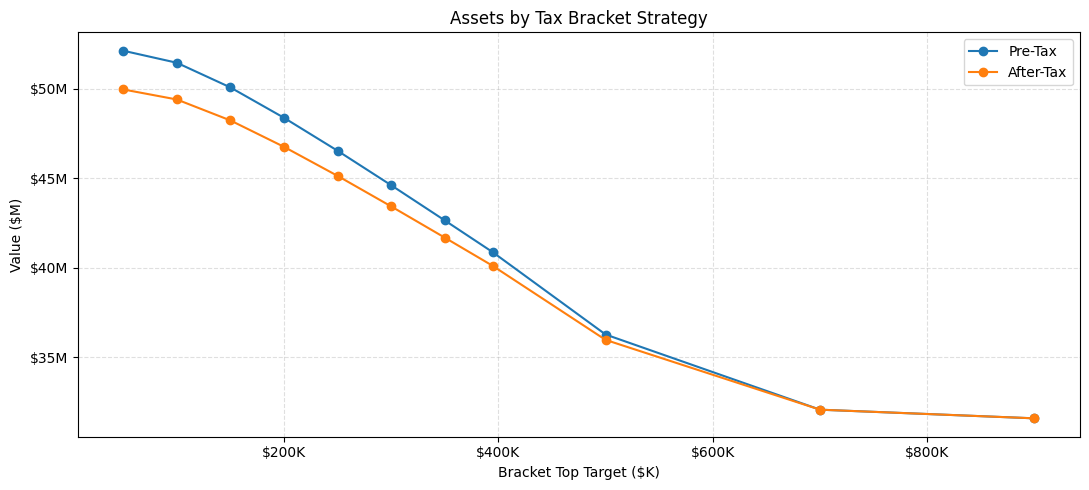

In [ ]:
targets = BRACKET_TARGETS

sweep_view = evaluate_roth_targets(
    scenario,
    targets,
    start_year=CONV_START_YEAR,
    end_year=CONV_END_YEAR,
    stop_at_rmd=True,
)
print(sweep_view[['bracket_top', 'final_after_tax_assets']])

import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(sweep_view['bracket_top'], sweep_view['final_total_assets'] / 1e6,
        marker='o', label='Pre-Tax')
ax.plot(sweep_view['bracket_top'], sweep_view['final_after_tax_assets'] / 1e6,
        marker='o', label='After-Tax')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_ylabel('Value ($M)')
ax.set_xlabel('Bracket Top Target ($K)')
ax.set_title('Assets by Tax Bracket Strategy')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_spending_levels(base_scenario, spending_levels):
    results = []

    # Save original spending
    original_spending = base_scenario.spending.base_spending

    for spend in spending_levels:

        # Update spending
        base_scenario.spending.base_spending = spend

        df_test = run_simulation(base_scenario)

        results.append({
            'spending': spend,
            'final_total_assets': df_test['end_total'].iloc[-1],
            'final_after_tax_assets': compute_after_tax_total(df_test),
            'total_tax': df_test['total_tax'].sum(),
            'max_rmd': df_test['rmd_required'].max(),
        })

    # Restore original spending
    base_scenario.spending.base_spending = original_spending

    return pd.DataFrame(results)

In [ ]:
spending_levels = SPENDING_LEVELS

spending_view = evaluate_spending_levels(
    base_scenario=scenario,
    spending_levels=spending_levels
)

display(spending_view)

,spending,final_total_assets,final_after_tax_assets,total_tax,max_rmd
0,120000,"43,730,583","42,965,929","2,088,960","212,276"
1,140000,"40,880,881","40,116,227","2,118,256","212,276"
2,160000,"37,994,383","37,229,729","2,154,043","212,276"
3,180000,"35,106,098","34,341,444","2,190,769","212,276"


In [ ]:
def find_optimal_roth_conversion(
    base_scenario,
    min_val=0,
    max_val=500000,
    step=10000,
    start_year=None,
    end_year=None,
    stop_at_rmd=False,
):
    """
    Sweep fixed annual Roth conversion amounts and find the one that
    maximises after-tax final assets.

    Uses strategy_type='fixed' matching the original architecture sweep.
    No start_year/end_year/stop_at_rmd constraints by default — conversions
    run every eligible year, self-limited by available traditional balance.
    """
    import numpy as np

    best_result      = None
    best_value       = -1
    opt_results_list = []

    for amount in np.arange(min_val, max_val + step, step):
        test_strategy = RothStrategy(
            strategy_type = "fixed",
            fixed_amount  = float(amount),
            start_year    = start_year,
            end_year      = end_year,
            stop_at_rmd   = stop_at_rmd,
        )

        test_scenario = clone_scenario_with_roth_strategy(base_scenario, test_strategy)
        df_sim        = run_simulation(test_scenario)
        after_tax     = compute_after_tax_total(df_sim)

        opt_results_list.append({
            "target":    float(amount),
            "after_tax": after_tax,
        })

        if after_tax > best_value:
            best_value  = after_tax
            best_result = float(amount)

    return best_result, opt_results_list


In [ ]:
# Coarse optimization pass
# Uses fixed annual conversion amount — matches original architecture
# No start_year/end_year/stop_at_rmd constraints
best_target, opt_results = find_optimal_roth_conversion(
    scenario,
    min_val  = 0,
    max_val  = OPTIMIZER_MAX,
    step     = 10000,
)

print(f"Coarse optimal annual conversion: ${best_target:,.0f}")


Coarse optimal annual conversion: $0


In [ ]:
# Refined optimization pass (step=$2K, ±$50K around coarse optimum)
best_target_refined, _ = find_optimal_roth_conversion(
    scenario,
    min_val = max(0, best_target - 50000),
    max_val = best_target + 50000,
    step    = 2000,
)

print(f"Refined optimal annual conversion: ${best_target_refined:,.0f}")


Refined optimal annual conversion: $0


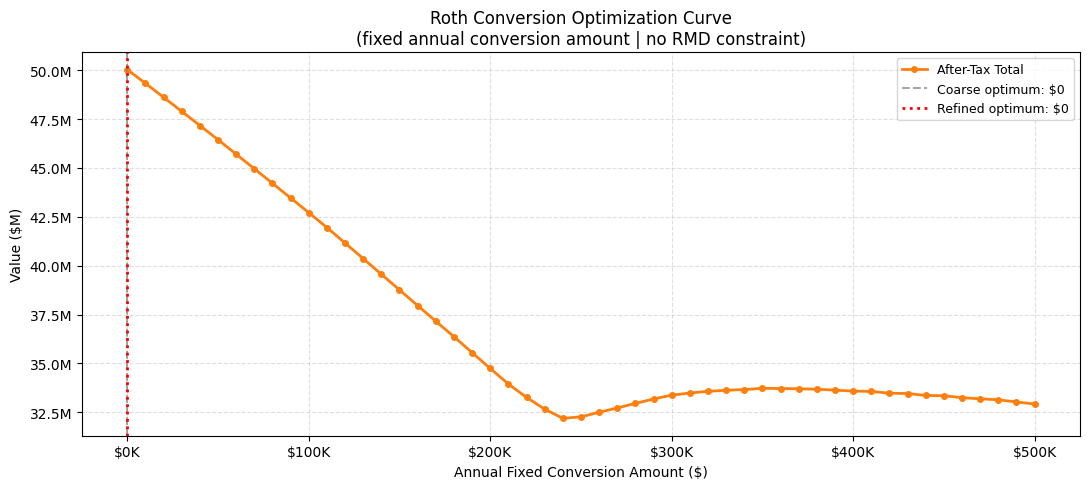


Summary:
  Coarse optimum:  $0
  Refined optimum: $0
  Best after-tax:  $50,029,653


In [ ]:
# Optimization curve — After-Tax wealth vs conversion target
df_opt = pd.DataFrame(opt_results)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_opt['target'], df_opt['after_tax'], marker='o', markersize=4,
        color='#ff7f0e', linewidth=2, label='After-Tax Total')

# Mark the coarse and refined optima
ax.axvline(best_target, color='grey', linestyle='--', alpha=0.7,
           label=f'Coarse optimum: ${best_target:,.0f}')
ax.axvline(best_target_refined, color='red', linestyle=':', linewidth=2,
           label=f'Refined optimum: ${best_target_refined:,.0f}')

format_currency_axis(ax, y_unit="M")
ax.set_title("Roth Conversion Optimization Curve\n(fixed annual conversion amount | no RMD constraint)", fontsize=12)
ax.set_xlabel("Annual Fixed Conversion Amount ($)")
ax.xaxis.set_major_formatter(
    __import__('matplotlib.ticker', fromlist=['FuncFormatter']).FuncFormatter(
        lambda x, _: f'${x/1000:.0f}K'
    )
)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Coarse optimum:  ${best_target:,.0f}")
print(f"  Refined optimum: ${best_target_refined:,.0f}")
print(f"  Best after-tax:  ${df_opt.loc[df_opt['after_tax'].idxmax(), 'after_tax']:,.0f}")


# New Section

In [ ]:
def optimize_roth_bracket(
    base_scenario: Scenario,
    min_income: int = 50000,
    max_income: int = 500000,
    step: int = 10000,
    start_year: Optional[int] = None,
    end_year: Optional[int] = None,
    stop_at_rmd: bool = True
):

    targets = generate_bracket_targets(min_income, max_income, step)

    results = evaluate_roth_targets(
        base_scenario=base_scenario,
        targets=targets,
        start_year=start_year,
        end_year=end_year,
        stop_at_rmd=stop_at_rmd
    )

    best_tax = results.sort_values('total_tax').iloc[0]
    best_assets = results.sort_values('final_total_assets', ascending=False).iloc[0]

    return {
        "all_results": results,
        "best_tax_strategy": best_tax,
        "best_asset_strategy": best_assets
    }

In [ ]:
optimizer_view = evaluate_roth_targets(
    base_scenario=scenario,
    targets=[96950, 206700, 394600, 501050],
    start_year=CONV_START_YEAR,
    end_year=CONV_END_YEAR,
    stop_at_rmd=True
)

optimizer_view

,bracket_top,final_total_assets,final_taxable,final_traditional,final_roth,final_cash,total_federal_tax,total_state_tax,total_tax,total_roth_conversion,first_rmd_year,max_rmd,ending_traditional_balance,ending_roth_balance,final_after_tax_assets
0,96950,"51,518,468","37,381,033","8,586,966","5,226,323","324,145","2,199,038","457,965","2,657,003","313,480",2038,"572,118","8,586,966","5,226,323","49,457,596"
1,206700,"48,137,294","30,496,011","6,635,973","10,681,166","324,145","1,910,690","438,839","2,349,529","1,597,140",2038,"442,131","6,635,973","10,681,166","46,544,661"
2,394600,"40,880,881","17,043,793","3,186,058","20,326,885","324,145","1,702,471","415,786","2,118,256","3,851,940",2038,"212,276","3,186,058","20,326,885","40,116,227"
3,501050,"36,231,178","8,884,013","1,231,596","25,791,424","324,145","1,725,266","406,044","2,131,310","5,129,340",2038,"82,057","1,231,596","25,791,424","35,935,595"


In [ ]:
optimizer = optimize_roth_bracket(
    base_scenario=scenario,
    min_income=50000,
    max_income=450000,
    step=10000,
    start_year=CONV_START_YEAR,
    end_year=CONV_END_YEAR,
    stop_at_rmd=True
)

In [ ]:
def evaluate_fixed_roth_amounts(
    base_scenario: Scenario,
    amounts: List[float],
    start_year: Optional[int] = None,
    end_year: Optional[int] = None,
    stop_at_rmd: bool = False
) -> pd.DataFrame:
    results = []

    for amount in amounts:
        test_strategy = RothStrategy(
            strategy_type='fixed',
            fixed_amount=amount,
            start_year=start_year,
            end_year=end_year,
            stop_at_rmd=stop_at_rmd
        )

        test_scenario = clone_scenario_with_roth_strategy(base_scenario, test_strategy)
        df_test = run_simulation(test_scenario)

        results.append({
            'fixed_amount': amount,
            'final_total_assets': df_test['end_total'].iloc[-1],
            'total_tax': df_test['total_tax'].sum(),
            'max_rmd': df_test['rmd_required'].max(),
            'ending_traditional_balance': df_test['end_traditional'].iloc[-1],
            'ending_roth_balance': df_test['end_roth'].iloc[-1],
            'total_roth_conversion': df_test['roth_conversion'].sum(),
        })

    return pd.DataFrame(results)

In [ ]:
fixed_optimizer_view = evaluate_fixed_roth_amounts(
    base_scenario=scenario,
    amounts=FIXED_AMOUNTS,
    start_year=CONV_START_YEAR,
    end_year=CONV_END_YEAR,
    stop_at_rmd=True
)

fixed_optimizer_view

,fixed_amount,final_total_assets,total_tax,max_rmd,ending_traditional_balance,ending_roth_balance,total_roth_conversion
0,0,"52,207,705","2,773,335","604,649","9,075,216","3,861,211",0
1,50000,"50,832,284","2,569,796","543,485","8,157,198","6,427,927","600,000"
2,100000,"49,301,907","2,422,245","482,320","7,239,179","8,994,643","1,200,000"
3,150000,"47,523,057","2,313,608","421,156","6,321,160","11,561,359","1,800,000"
4,200000,"45,640,854","2,233,261","359,992","5,403,141","14,128,076","2,400,000"
5,300000,"41,719,555","2,133,303","237,663","3,567,104","19,261,508","3,600,000"


In [ ]:
df.loc[(df['year'] >= 2037) & (df['year'] <= 2042), [
    'year',
    'you_age',
    'gross_nonportfolio_income',
    'roth_conversion',
    'rmd_required',
    'withdrawal_traditional_cash',
    'gross_taxable_income',
    'taxable_income',
    'total_tax',
    'end_traditional',
    'end_roth'
]]

,year,you_age,gross_nonportfolio_income,roth_conversion,rmd_required,withdrawal_traditional_cash,gross_taxable_income,taxable_income,total_tax,end_traditional,end_roth
11,2037,72,"266,557","314,323",0,0,"400,176","370,176","90,692","2,900,188","6,617,850"
12,2038,73,"271,408",0,"109,441","109,441","191,064","161,064","32,510","2,930,284","6,948,743"
13,2039,74,"276,356",0,"114,913","114,913","197,909","167,909","34,324","2,956,140","7,296,180"
14,2040,75,"281,403",0,"120,168","120,168","204,564","174,564","36,087","2,977,770","7,660,989"
15,2041,76,"286,551",0,"125,644","125,644","211,468","181,468","37,917","2,994,732","8,044,039"
16,2042,77,"291,802",0,"130,774","130,774","218,054","188,054","39,662","3,007,156","8,446,241"


In [ ]:
df[[
    'year',
    'withdrawal_taxable',
    'taxable_principal_returned',
    'realized_capital_gain',
    'gross_capital_gains_income',
    'federal_capital_gains_tax',
    'total_tax'
]].head(15)

,year,withdrawal_taxable,taxable_principal_returned,realized_capital_gain,gross_capital_gains_income,federal_capital_gains_tax,total_tax
0,2026,0,0,0,0,0,"89,605"
1,2027,0,0,0,0,0,"89,605"
2,2028,0,0,0,0,0,"89,605"
3,2029,"106,258","49,227","57,031","57,031","8,555","100,726"
4,2030,"166,623","74,009","92,614","92,614","13,892","107,665"
5,2031,"72,937","31,167","41,770","41,770","6,265","97,750"
6,2032,"71,717","29,329","42,388","42,388","6,358","97,871"
7,2033,"71,603","28,027","43,577","43,577","6,536","98,102"
8,2034,"71,506","26,792","44,714","44,714","6,707","98,324"
9,2035,"71,412","25,616","45,796","45,796","6,869","98,535"


In [ ]:
df[[
    'year',
    'end_taxable',
    'end_taxable_cost_basis',
    'taxable_account_unrealized_gain'
]].head(15)

,year,end_taxable,end_taxable_cost_basis,taxable_account_unrealized_gain
0,2026,"1,562,699","797,699","765,000"
1,2027,"1,640,834","797,699","843,135"
2,2028,"1,722,876","797,699","925,177"
3,2029,"1,686,872","748,472","938,401"
4,2030,"1,579,140","674,463","904,677"
5,2031,"1,573,818","643,296","930,522"
6,2032,"1,569,422","613,967","955,455"
7,2033,"1,564,731","585,940","978,791"
8,2034,"1,559,724","559,148","1,000,576"
9,2035,"1,554,391","533,533","1,020,858"


In [ ]:
df[['year', 'rental_income', 'taxable_nonportfolio_income', 'gross_taxable_income', 'total_tax']].head(10)

,year,rental_income,taxable_nonportfolio_income,gross_taxable_income,total_tax
0,2026,"120,000","112,000","394,600","89,605"
1,2027,"122,400","115,240","394,600","89,605"
2,2028,"124,848","12,485","394,600","89,605"
3,2029,"127,345","36,734","451,631","100,726"
4,2030,"129,892","36,989","487,214","107,665"
5,2031,"132,490","37,249","436,370","97,750"
6,2032,"135,139","37,514","436,988","97,871"
7,2033,"137,842","37,784","438,177","98,102"
8,2034,"140,599","38,060","439,314","98,324"
9,2035,"143,411","38,341","440,396","98,535"


In [ ]:
df.loc[(df['year'] >= 2028) & (df['year'] <= 2035), [
    'year',
    'ss_you',
    'ss_spouse',
    'combined_income',
    'taxable_social_security',
    'roth_conversion',
    'gross_ordinary_income',
    'total_tax'
]]

,year,ss_you,ss_spouse,combined_income,taxable_social_security,roth_conversion,gross_ordinary_income,total_tax
2,2028,0,"39,600","32,285",142,"381,973","394,600","89,605"
3,2029,0,"40,392","56,930","16,991","340,875","394,600","100,726"
4,2030,0,"41,200","57,589","17,551","340,060","394,600","107,665"
5,2031,"40,870","42,024","78,696","35,492","321,860","394,600","97,750"
6,2032,"41,687","42,864","79,790","36,421","320,665","394,600","97,871"
7,2033,"42,521","43,722","80,906","37,370","319,446","394,600","98,102"
8,2034,"43,372","44,596","82,044","38,337","318,203","394,600","98,324"
9,2035,"44,239","45,488","83,205","39,324","316,935","394,600","98,535"


In [ ]:
# ============================================================
# Annual Tax View
# ============================================================

tax_view = df[[
    'year', 'you_age', 'spouse_age',
    'salary_you', 'salary_spouse', 'rental_income',
    'pension_you', 'pension_spouse', 'ss_you', 'ss_spouse',
    'gross_nonportfolio_income',
    'rmd_required',
    'roth_conversion',
    'realized_capital_gain',
    'gross_ordinary_income',
    'gross_capital_gains_income',
    'gross_taxable_income',
    'deduction',
    'taxable_ordinary_income',
    'taxable_capital_gains',
    'taxable_income',
    'federal_ordinary_tax',
    'federal_capital_gains_tax',
    'federal_tax',
    'state_tax',
    'total_tax',
]].copy()

tax_view['earned_income']          = tax_view['salary_you'] + tax_view['salary_spouse']
tax_view['pension_income']         = tax_view['pension_you'] + tax_view['pension_spouse']
tax_view['social_security_income'] = tax_view['ss_you'] + tax_view['ss_spouse']

tax_view = tax_view[[
    'year', 'you_age', 'spouse_age',
    'earned_income', 'rental_income', 'pension_income', 'social_security_income',
    'gross_nonportfolio_income',
    'rmd_required', 'roth_conversion', 'realized_capital_gain',
    'gross_ordinary_income',
    'gross_capital_gains_income',
    'gross_taxable_income',
    'deduction',
    'taxable_ordinary_income',
    'taxable_capital_gains',
    'taxable_income',
    'federal_ordinary_tax', 'federal_capital_gains_tax',
    'federal_tax', 'state_tax', 'total_tax',
]].rename(columns={
    'you_age':                     'Your Age',
    'spouse_age':                  'Spouse Age',
    'earned_income':               'Earned Income',
    'rental_income':               'Rental Income',
    'pension_income':              'Pension Income',
    'social_security_income':      'Social Security',
    'gross_nonportfolio_income':   'Gross Non-Portfolio Income',
    'rmd_required':                'RMD',
    'roth_conversion':             'Roth Conversion',
    'realized_capital_gain':       'Realized Capital Gains',
    'gross_ordinary_income':       'Gross Ordinary Income',
    'gross_capital_gains_income':  'Gross Capital Gains',
    'gross_taxable_income':        'Gross Total Income',
    'deduction':                   'Standard Deduction',
    'taxable_ordinary_income':     'Taxable Ordinary Income',
    'taxable_capital_gains':       'Taxable Capital Gains',
    'taxable_income':              'Taxable Income',
    'federal_ordinary_tax':        'Federal Ordinary Tax',
    'federal_capital_gains_tax':   'Federal Capital Gains Tax',
    'federal_tax':                 'Federal Tax',
    'state_tax':                   'State Tax',
    'total_tax':                   'Total Tax',
})

tax_view.head(20)


,year,Your Age,Spouse Age,Earned Income,Rental Income,Pension Income,Social Security,Gross Non-Portfolio Income,RMD,Roth Conversion,Realized Capital Gains,Gross Ordinary Income,Gross Capital Gains,Gross Total Income,Standard Deduction,Taxable Ordinary Income,Taxable Capital Gains,Taxable Income,Federal Ordinary Tax,Federal Capital Gains Tax,Federal Tax,State Tax,Total Tax
0,2026,61,63,"100,000","120,000",0,0,"220,000",0,"282,600",0,"394,600",0,"394,600",30000,"364,600",0,"364,600","73,198",0,"73,198","16,407","89,605"
1,2027,62,64,"103,000","122,400",0,0,"225,400",0,"279,360",0,"394,600",0,"394,600",30000,"364,600",0,"364,600","73,198",0,"73,198","16,407","89,605"
2,2028,63,65,0,"124,848",0,"39,600","164,448",0,"381,973",0,"394,600",0,"394,600",30000,"364,600",0,"364,600","73,198",0,"73,198","16,407","89,605"
3,2029,64,66,0,"127,345","24,000","40,392","191,737",0,"340,875","57,031","394,600","57,031","451,631",30000,"364,600","57,031","421,631","73,198","8,555","81,753","18,973","100,726"
4,2030,65,67,0,"129,892","24,000","41,200","195,092",0,"340,060","92,614","394,600","92,614","487,214",30000,"364,600","92,614","457,214","73,198","13,892","87,090","20,575","107,665"
5,2031,66,68,0,"132,490","24,000","82,894","239,384",0,"321,860","41,770","394,600","41,770","436,370",30000,"364,600","41,770","406,370","73,198","6,265","79,463","18,287","97,750"
6,2032,67,69,0,"135,139","24,000","84,552","243,691",0,"320,665","42,388","394,600","42,388","436,988",30000,"364,600","42,388","406,988","73,198","6,358","79,556","18,314","97,871"
7,2033,68,70,0,"137,842","24,000","86,243","248,085",0,"319,446","43,577","394,600","43,577","438,177",30000,"364,600","43,577","408,177","73,198","6,536","79,734","18,368","98,102"
8,2034,69,71,0,"140,599","24,000","87,968","252,567",0,"318,203","44,714","394,600","44,714","439,314",30000,"364,600","44,714","409,314","73,198","6,707","79,905","18,419","98,324"
9,2035,70,72,0,"143,411","24,000","89,727","257,138",0,"316,935","45,796","394,600","45,796","440,396",30000,"364,600","45,796","410,396","73,198","6,869","80,067","18,468","98,535"


In [ ]:
# ============================================================
# Retirement Planner Dashboard View
# ============================================================

planner_view = df[[
    'year', 'you_age', 'spouse_age',
    'gross_nonportfolio_income',
    'gross_ordinary_income',
    'roth_conversion',
    'rmd_required',
    'realized_capital_gain',
    'taxable_income',
    'total_spending',
    'total_tax',
    'withdrawal_cash',
    'withdrawal_taxable',
    'withdrawal_traditional_cash',
    'withdrawal_roth',
    'end_taxable',
    'taxable_account_unrealized_gain',
    'end_traditional',
    'end_roth',
    'end_cash',
    'end_total',
]].copy()

planner_view['total_withdrawals'] = (
    planner_view['withdrawal_cash']
    + planner_view['withdrawal_taxable']
    + planner_view['withdrawal_traditional_cash']
    + planner_view['withdrawal_roth']
)

planner_view['investment_portfolio_total'] = (
    planner_view['end_taxable']
    + planner_view['end_traditional']
    + planner_view['end_roth']
)

planner_view = planner_view[[
    'year', 'you_age', 'spouse_age',
    'gross_nonportfolio_income',
    'gross_ordinary_income',
    'rmd_required',
    'roth_conversion',
    'realized_capital_gain',
    'taxable_income',
    'total_spending',
    'total_tax',
    'total_withdrawals',
    'withdrawal_cash',
    'withdrawal_taxable',
    'withdrawal_traditional_cash',
    'withdrawal_roth',
    'end_taxable',
    'taxable_account_unrealized_gain',
    'end_traditional',
    'end_roth',
    'end_cash',
    'end_total',
    'investment_portfolio_total',
]].rename(columns={
    'you_age':                         'Your Age',
    'spouse_age':                      'Spouse Age',
    'gross_nonportfolio_income':       'Gross Non-Portfolio Income',
    'gross_ordinary_income':           'Gross Ordinary Income',
    'rmd_required':                    'RMD',
    'roth_conversion':                 'Roth Conversion',
    'realized_capital_gain':           'Realized Capital Gains',
    'taxable_income':                  'Taxable Income',
    'total_spending':                  'Total Spending',
    'total_tax':                       'Total Tax',
    'total_withdrawals':               'Total Withdrawals',
    'withdrawal_cash':                 'Cash Withdrawal',
    'withdrawal_taxable':              'Brokerage Withdrawal',
    'withdrawal_traditional_cash':     'IRA Withdrawal',
    'withdrawal_roth':                 'Roth Withdrawal',
    'end_taxable':                     'Ending Brokerage',
    'taxable_account_unrealized_gain': 'Unrealized Gains (Brokerage)',
    'end_traditional':                 'Ending IRA',
    'end_roth':                        'Ending Roth',
    'end_cash':                        'Ending Cash',
    'end_total':                       'Total Assets',
    'investment_portfolio_total':      'Investment Portfolio Total',
})

planner_view


,year,Your Age,Spouse Age,Gross Non-Portfolio Income,Gross Ordinary Income,RMD,Roth Conversion,Realized Capital Gains,Taxable Income,Total Spending,Total Tax,Total Withdrawals,Cash Withdrawal,Brokerage Withdrawal,IRA Withdrawal,Roth Withdrawal,Ending Brokerage,Unrealized Gains (Brokerage),Ending IRA,Ending Roth,Ending Cash,Total Assets,Investment Portfolio Total
0,2026,61,63,"220,000","394,600",0,"282,600",0,"364,600","195,200","89,605","64,805","64,805",0,0,0,"1,562,699","765,000","4,533,270","1,031,730","195,200","7,322,899","7,127,699"
1,2027,62,64,"225,400","394,600",0,"279,360",0,"364,600","198,700","89,605","62,905","62,905",0,0,0,"1,640,834","843,135","4,466,606","1,376,644","134,941","7,619,025","7,484,084"
2,2028,63,65,"164,448","394,600",0,"381,973",0,"364,600","202,288","89,605","127,444","127,444",0,0,0,"1,722,876","925,177","4,288,864","1,846,548","7,646","7,865,934","7,858,288"
3,2029,64,66,"191,737","394,600",0,"340,875","57,031","421,631","205,965","100,726","113,905","7,646","106,258",0,0,"1,686,872","938,401","4,145,389","2,296,794","-1,070","8,127,985","8,129,055"
4,2030,65,67,"195,092","394,600",0,"340,060","92,614","457,214","254,734","107,665","165,553","-1,070","166,623",0,0,"1,579,140","904,677","3,995,596","2,768,697","-1,789","8,341,644","8,343,432"
5,2031,66,68,"239,384","394,600",0,"321,860","41,770","406,370","213,597","97,750","71,148","-1,789","72,937",0,0,"1,573,818","930,522","3,857,423","3,245,084",-832,"8,675,493","8,676,325"
6,2032,67,69,"243,691","394,600",0,"320,665","42,388","406,988","217,557","97,871","70,885",-832,"71,717",0,0,"1,569,422","955,455","3,713,596","3,744,036",-869,"9,026,185","9,027,054"
7,2033,68,70,"248,085","394,600",0,"319,446","43,577","408,177","221,616","98,102","70,734",-869,"71,603",0,0,"1,564,731","978,791","3,563,858","4,266,656",-917,"9,394,328","9,395,245"
8,2034,69,71,"252,567","394,600",0,"318,203","44,714","409,314","225,776","98,324","70,589",-917,"71,506",0,0,"1,559,724","1,000,576","3,407,937","4,814,102",-964,"9,780,800","9,781,764"
9,2035,70,72,"257,138","394,600",0,"316,935","45,796","410,396","230,041","98,535","70,448",-964,"71,412",0,0,"1,554,391","1,020,858","3,245,553","5,387,589","-1,010","10,186,522","10,187,532"


In [ ]:
# evaluate_spending_levels is defined above (Cell 38) — duplicate removed.
# The duplicate here incorrectly called run_simulation with an unsupported argument.


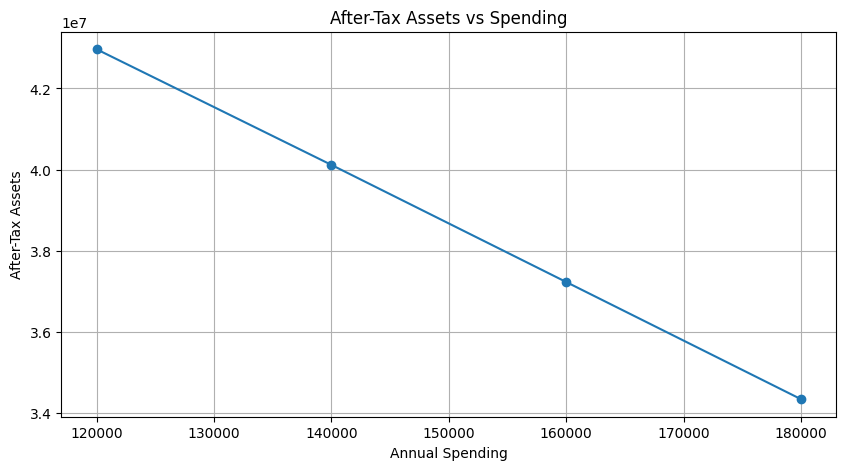

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(spending_view['spending'], spending_view['final_after_tax_assets'], marker='o')

plt.title('After-Tax Assets vs Spending')
plt.xlabel('Annual Spending')
plt.ylabel('After-Tax Assets')
plt.grid(True)

plt.show()

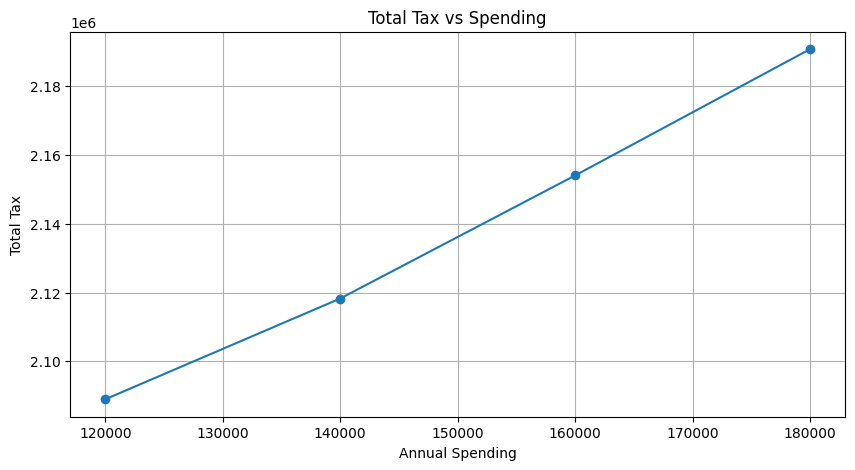

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(spending_view['spending'], spending_view['total_tax'], marker='o')

plt.title('Total Tax vs Spending')
plt.xlabel('Annual Spending')
plt.ylabel('Total Tax')
plt.grid(True)

plt.show()

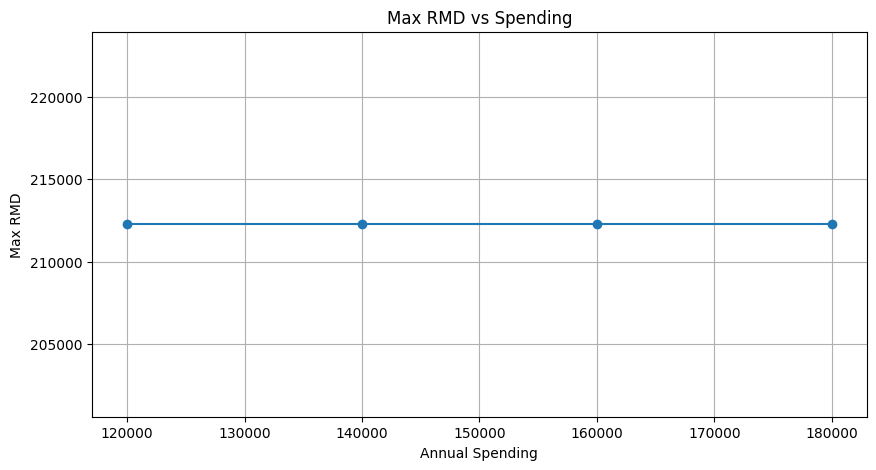

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(spending_view['spending'], spending_view['max_rmd'], marker='o')

plt.title('Max RMD vs Spending')
plt.xlabel('Annual Spending')
plt.ylabel('Max RMD')
plt.grid(True)

plt.show()

In [ ]:
def run_sensitivity_grid(base_scenario, return_rates, end_years, spending_levels):
    results = []

    # Save originals
    original_spending = base_scenario.spending.base_spending
    original_end_year = base_scenario.simulation.end_year
    original_returns = [acct.annual_return for acct in base_scenario.accounts]

    for r in return_rates:
        for year in end_years:
            for spend in spending_levels:

                # Apply values
                base_scenario.simulation.end_year = year
                base_scenario.spending.base_spending = spend

                for acct in base_scenario.accounts:
                    acct.annual_return = r

                df = run_simulation(base_scenario)

                results.append({
                    'return_rate': r*100, # 100 to make a %
                    'end_year': year,
                    'spending': spend,
                    'after_tax_assets': compute_after_tax_total(df)
                })

    # Restore originals
    base_scenario.spending.base_spending = original_spending
    base_scenario.simulation.end_year = original_end_year

    for acct, r in zip(base_scenario.accounts, original_returns):
        acct.annual_return = r

    return pd.DataFrame(results)

In [ ]:
return_rates = RETURN_RATES
end_years = GRID_END_YEARS
spending_levels = GRID_SPENDING_LEVELS

grid = run_sensitivity_grid(
    scenario,
    return_rates,
    end_years,
    spending_levels
)

display(grid)

,return_rate,end_year,spending,after_tax_assets
0,5,2045,120000,"18,449,403"
1,5,2045,140000,"17,489,592"
2,5,2045,160000,"16,514,541"
3,5,2045,200000,"14,559,114"
4,5,2045,220000,"13,319,403"
5,5,2050,120000,"25,079,360"
6,5,2050,140000,"23,654,962"
7,5,2050,160000,"22,211,112"
8,5,2050,200000,"19,316,619"
9,5,2050,220000,"17,478,702"


In [ ]:
pivot = grid[grid['spending'] == SPENDING_LEVELS[1]].pivot(
    index='return_rate',
    columns='end_year',
    values='after_tax_assets'
)

display(pivot)

end_year,2045,2050,2055
return_rate,,,
5,"17,489,592","23,654,962","31,693,678"
6,"21,130,927","29,969,745","42,110,324"
7,"25,494,496","37,913,422","55,830,766"


## 14. Summary Views

In [ ]:
# ============================================================
# Quick Annual Summary
# ============================================================

summary_view = df[[
    'year', 'you_age', 'spouse_age',
    'gross_nonportfolio_income',
    'gross_ordinary_income',
    'taxable_income',
    'total_spending', 'total_tax',
    'rmd_required', 'roth_conversion',
    'end_taxable', 'end_traditional', 'end_roth', 'end_cash', 'end_total'
]].rename(columns={
    'you_age':                   'Your Age',
    'spouse_age':                'Spouse Age',
    'gross_nonportfolio_income': 'Gross Non-Portfolio Income',
    'gross_ordinary_income':     'Gross Ordinary Income',
    'taxable_income':            'Taxable Income',
    'total_spending':            'Total Spending',
    'total_tax':                 'Total Tax',
    'rmd_required':              'RMD',
    'roth_conversion':           'Roth Conversion',
    'end_taxable':               'Ending Brokerage',
    'end_traditional':           'Ending IRA',
    'end_roth':                  'Ending Roth',
    'end_cash':                  'Ending Cash',
    'end_total':                 'Total Assets',
})

summary_view.head(20)


,year,Your Age,Spouse Age,Gross Non-Portfolio Income,Gross Ordinary Income,Taxable Income,Total Spending,Total Tax,RMD,Roth Conversion,Ending Brokerage,Ending IRA,Ending Roth,Ending Cash,Total Assets
0,2026,61,63,"220,000","394,600","364,600","195,200","89,605",0,"282,600","1,562,699","4,533,270","1,031,730","195,200","7,322,899"
1,2027,62,64,"225,400","394,600","364,600","198,700","89,605",0,"279,360","1,640,834","4,466,606","1,376,644","134,941","7,619,025"
2,2028,63,65,"164,448","394,600","364,600","202,288","89,605",0,"381,973","1,722,876","4,288,864","1,846,548","7,646","7,865,934"
3,2029,64,66,"191,737","394,600","421,631","205,965","100,726",0,"340,875","1,686,872","4,145,389","2,296,794","-1,070","8,127,985"
4,2030,65,67,"195,092","394,600","457,214","254,734","107,665",0,"340,060","1,579,140","3,995,596","2,768,697","-1,789","8,341,644"
5,2031,66,68,"239,384","394,600","406,370","213,597","97,750",0,"321,860","1,573,818","3,857,423","3,245,084",-832,"8,675,493"
6,2032,67,69,"243,691","394,600","406,988","217,557","97,871",0,"320,665","1,569,422","3,713,596","3,744,036",-869,"9,026,185"
7,2033,68,70,"248,085","394,600","408,177","221,616","98,102",0,"319,446","1,564,731","3,563,858","4,266,656",-917,"9,394,328"
8,2034,69,71,"252,567","394,600","409,314","225,776","98,324",0,"318,203","1,559,724","3,407,937","4,814,102",-964,"9,780,800"
9,2035,70,72,"257,138","394,600","410,396","230,041","98,535",0,"316,935","1,554,391","3,245,553","5,387,589","-1,010","10,186,522"


## 15. Basic Charts

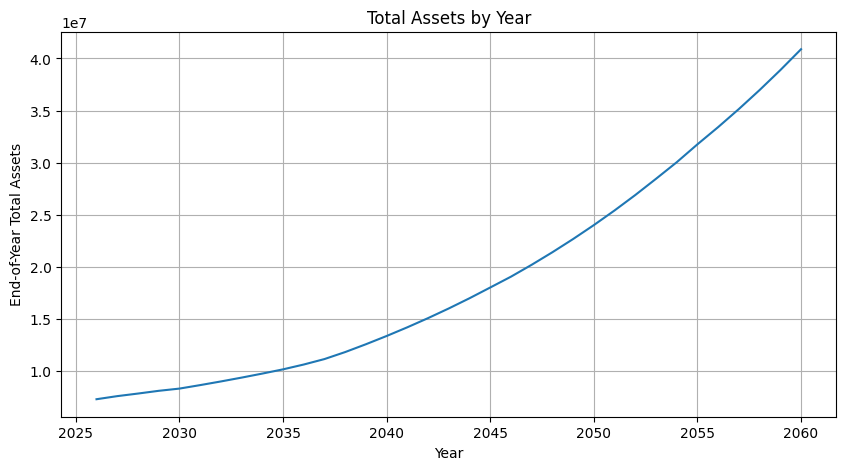

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['year'], df['end_total'])
plt.title('Total Assets by Year')
plt.xlabel('Year')
plt.ylabel('End-of-Year Total Assets')
plt.grid(True)
plt.show()

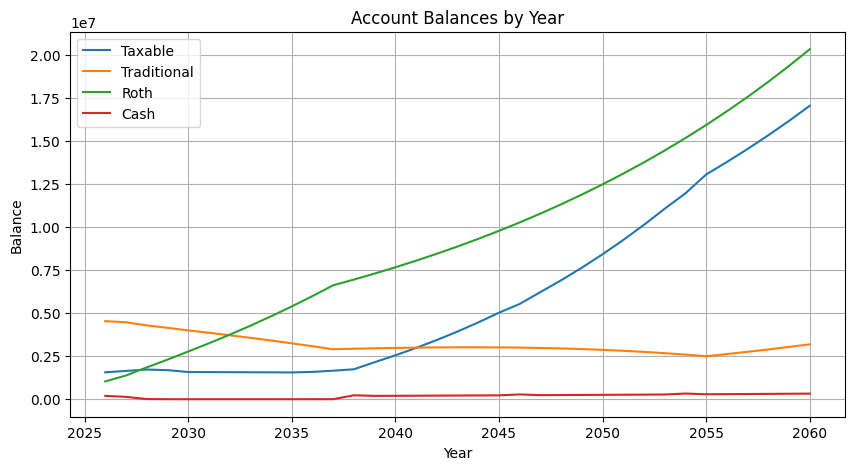

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['year'], df['end_taxable'], label='Taxable')
plt.plot(df['year'], df['end_traditional'], label='Traditional')
plt.plot(df['year'], df['end_roth'], label='Roth')
plt.plot(df['year'], df['end_cash'], label='Cash')
plt.title('Account Balances by Year')
plt.xlabel('Year')
plt.ylabel('Balance')
plt.legend()
plt.grid(True)
plt.show()

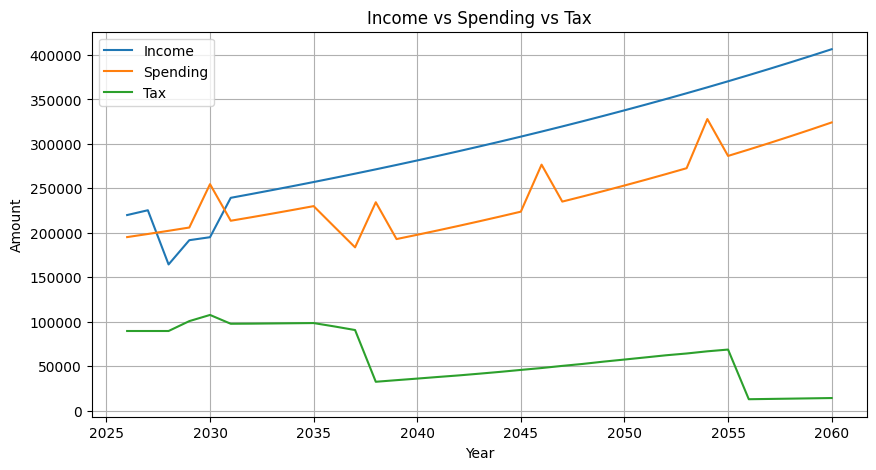

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['year'], df['gross_nonportfolio_income'], label='Income')
plt.plot(df['year'], df['total_spending'], label='Spending')
plt.plot(df['year'], df['total_tax'], label='Tax')
plt.title('Income vs Spending vs Tax')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

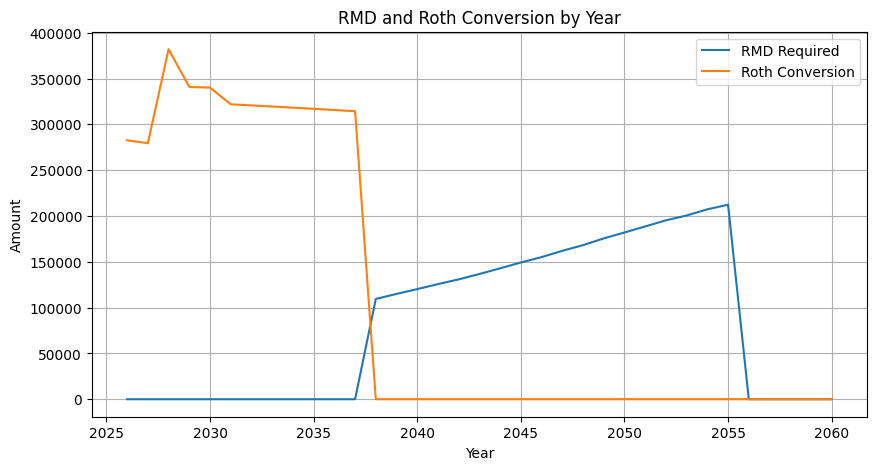

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['year'], df['rmd_required'], label='RMD Required')
plt.plot(df['year'], df['roth_conversion'], label='Roth Conversion')
plt.title('RMD and Roth Conversion by Year')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

## 16. Next Improvements

Good next upgrades after this starter version:
1. Replace sample inputs with your real inputs.
2. Improve Social Security taxation.
3. Improve state tax handling.
4. Add bracket-fill Roth conversion.
5. Separate your accounts and spouse accounts if needed.
6. Add scenario comparison.
7. Add IRMAA later.
8. Add Monte Carlo much later.

## Strategy Dashboard

Year-by-year comparison of 4 Roth conversion strategies.
Each strategy runs 2028–2037 with stop_at_rmd=True.

In [ ]:
# ============================================================
# STRATEGY DASHBOARD
# 4 strategies x 2-panel year-by-year view + comparison chart
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- Define the 4 strategies ---
# Fill bracket strategies start 2026 — self-regulate, no room = no conversion
# Fixed strategies also start 2026 — sized to stay within 24% bracket
strategies = {
    'Fill 22% Bracket': RothStrategy(
        strategy_type='fill_bracket',
        bracket_top=DASHBOARD_BRACKET_22,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=CONV_STOP_AT_RMD,
    ),
    'Fill 24% Bracket': RothStrategy(
        strategy_type='fill_bracket',
        bracket_top=DASHBOARD_BRACKET_24,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=CONV_STOP_AT_RMD,
    ),
    'Fixed $200K/yr': RothStrategy(
        strategy_type='fixed',
        fixed_amount=DASHBOARD_FIXED_1,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=CONV_STOP_AT_RMD,
    ),
    'Fixed $500K/yr': RothStrategy(
        strategy_type='fixed',
        fixed_amount=DASHBOARD_FIXED_2,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=CONV_STOP_AT_RMD,
    ),
}

# --- Run simulations ---
dashboard_results = {}
for name, strat in strategies.items():
    sc = clone_scenario_with_roth_strategy(scenario, strat)
    df_s = run_simulation(sc)

    # Derived columns — conventional names
    df_s['after_tax_total'] = (
        df_s['end_taxable']
        + df_s['end_roth']
        + df_s['end_traditional'] * (1 - HAIRCUT_RATE)
        + df_s['end_cash']
    )
    df_s['total_available_to_spend'] = (
        df_s['gross_nonportfolio_income']
        + df_s['withdrawal_cash']
        + df_s['withdrawal_taxable']
        + df_s['withdrawal_traditional_cash']
        + df_s['withdrawal_roth']
        - df_s['total_tax']
    )
    dashboard_results[name] = df_s
    print(f"Simulated: {name}")

print("All simulations done.")

# ── Auto-generate strategy colors ────────────────────────────────────────
# Defined once here so all downstream cells use consistent colors
# with no hardcoded strategy names
_color_cycle = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
]
strat_colors = {
    name: _color_cycle[i % len(_color_cycle)]
    for i, name in enumerate(dashboard_results.keys())
}
print("Strategy colors:", strat_colors)


Simulated: Fill 22% Bracket
Simulated: Fill 24% Bracket
Simulated: Fixed $200K/yr
Simulated: Fixed $500K/yr
All simulations done.
Strategy colors: {'Fill 22% Bracket': '#1f77b4', 'Fill 24% Bracket': '#ff7f0e', 'Fixed $200K/yr': '#2ca02c', 'Fixed $500K/yr': '#d62728'}


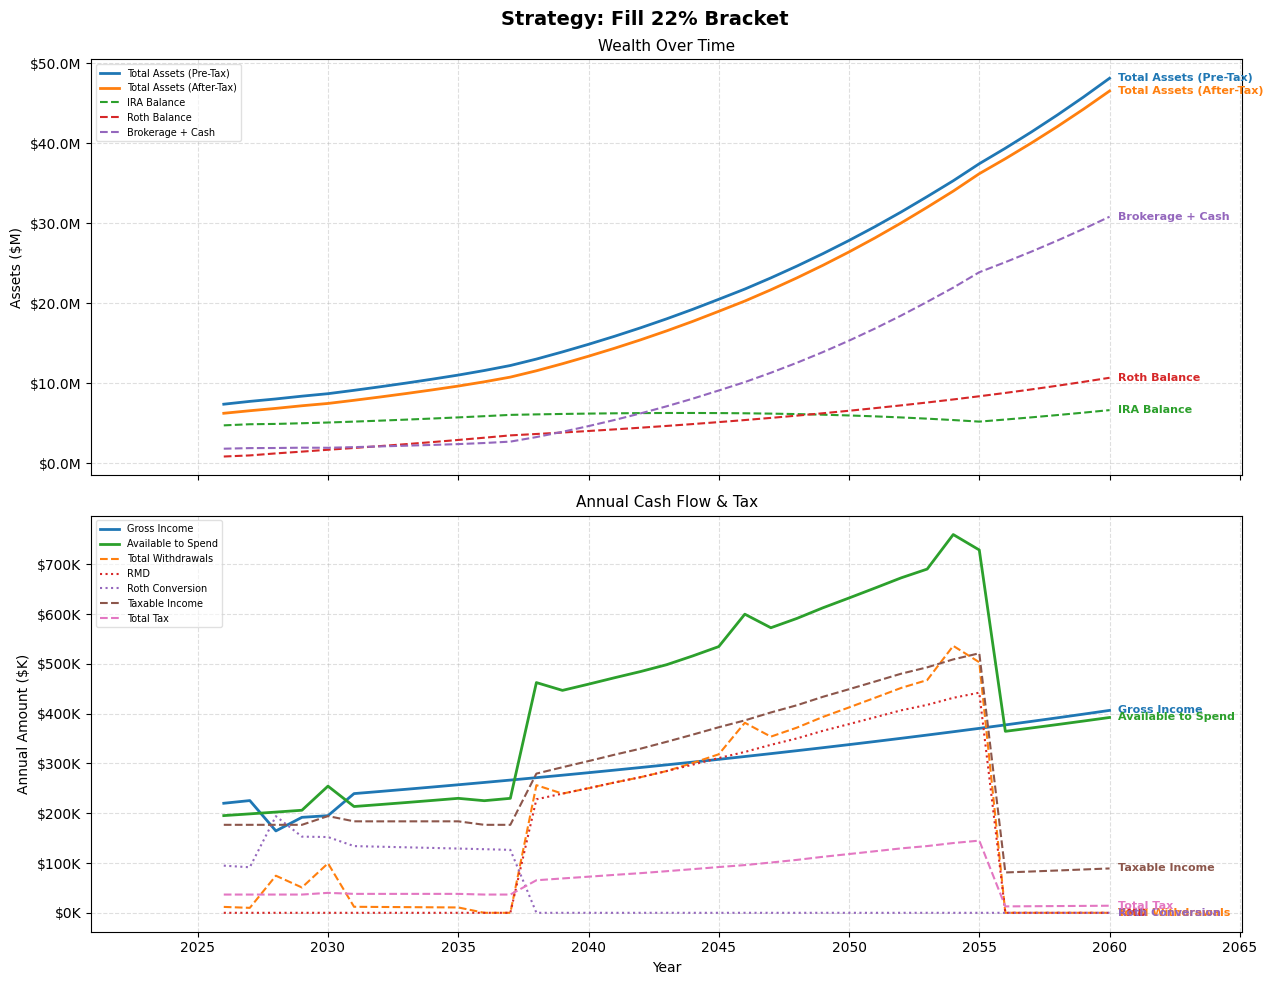

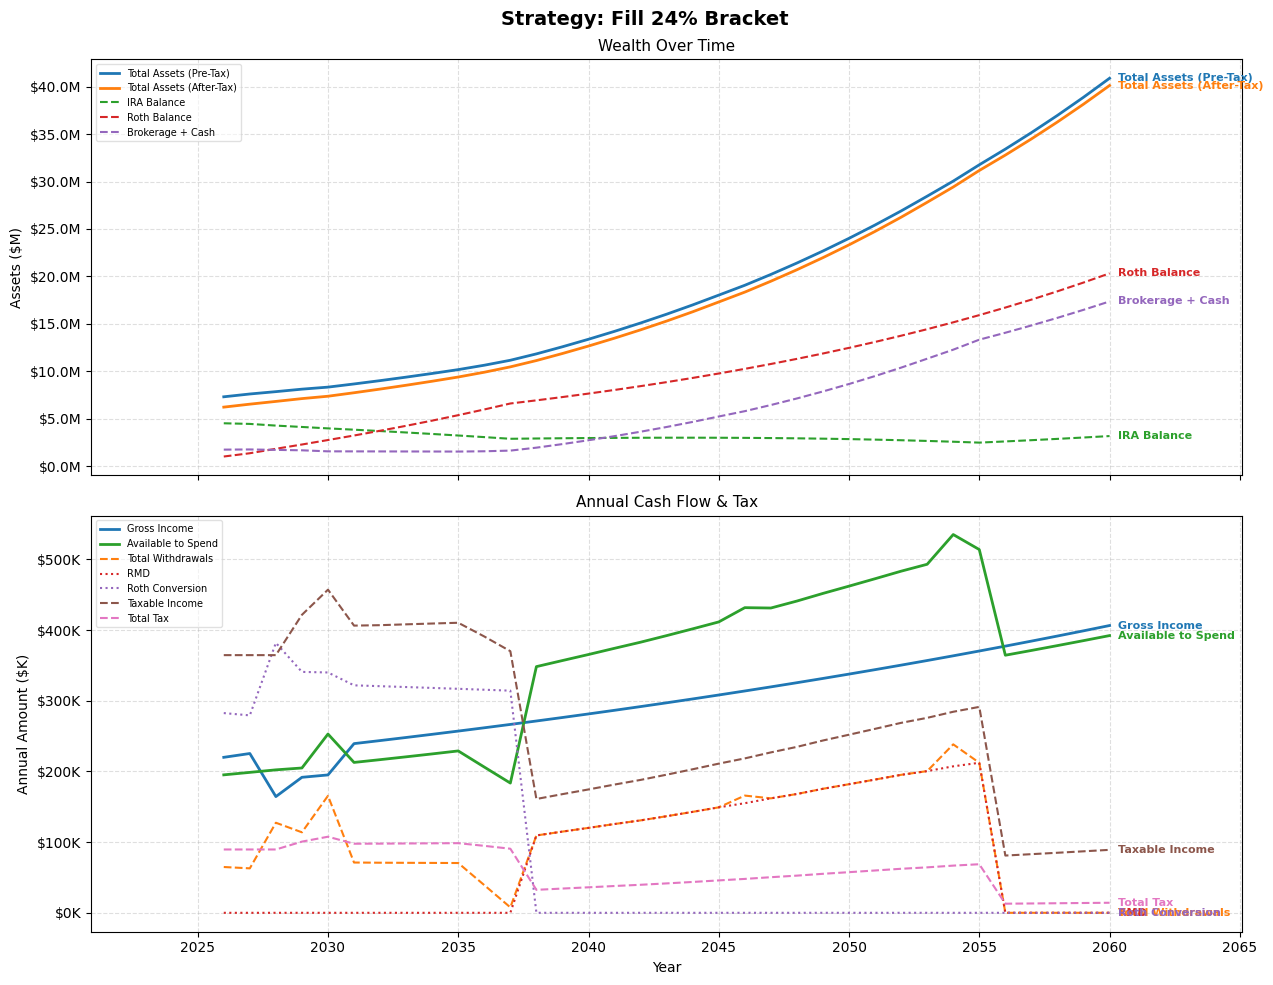

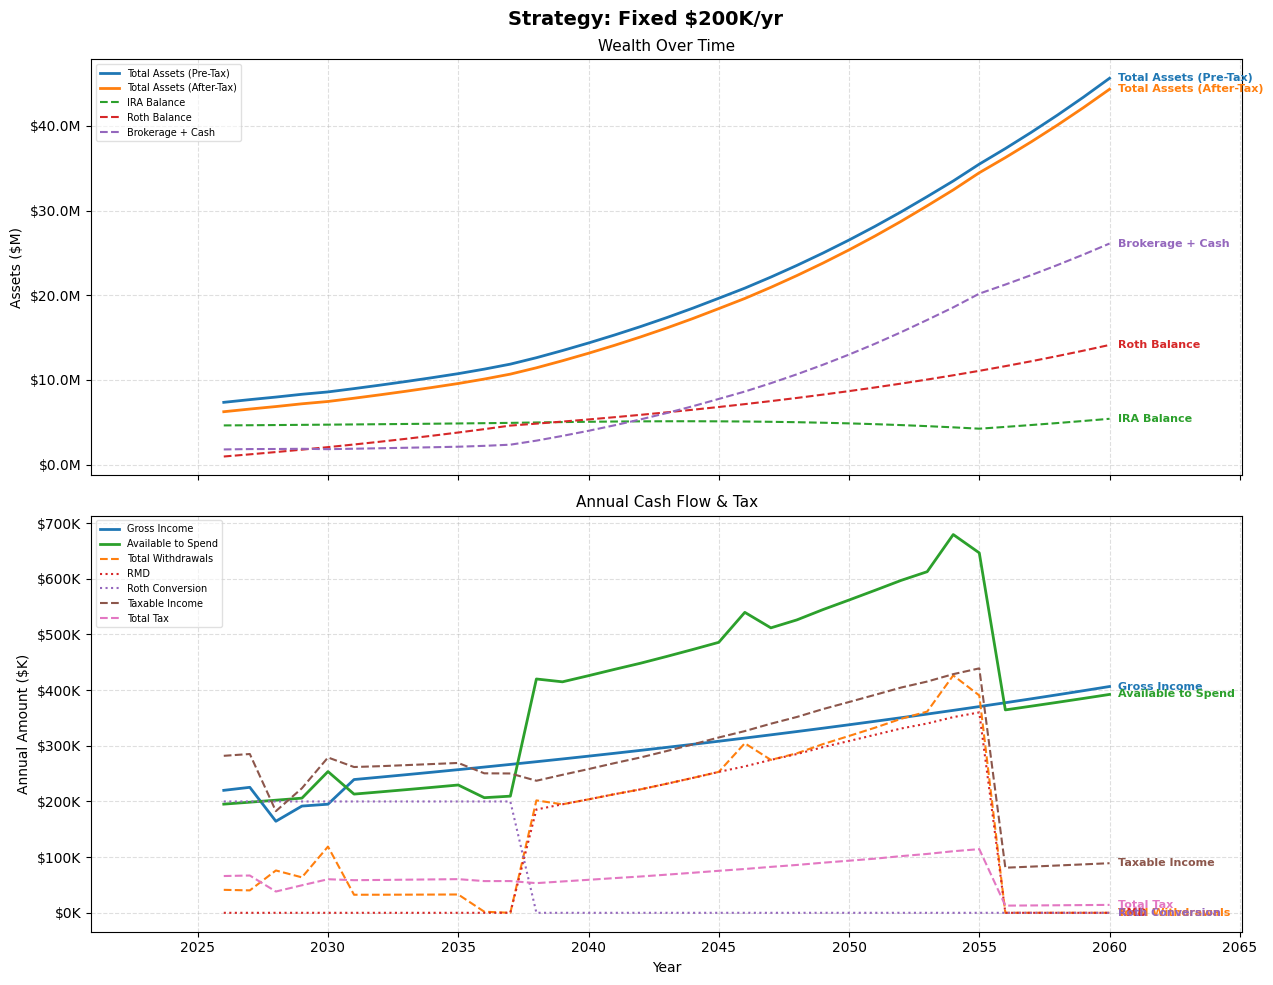

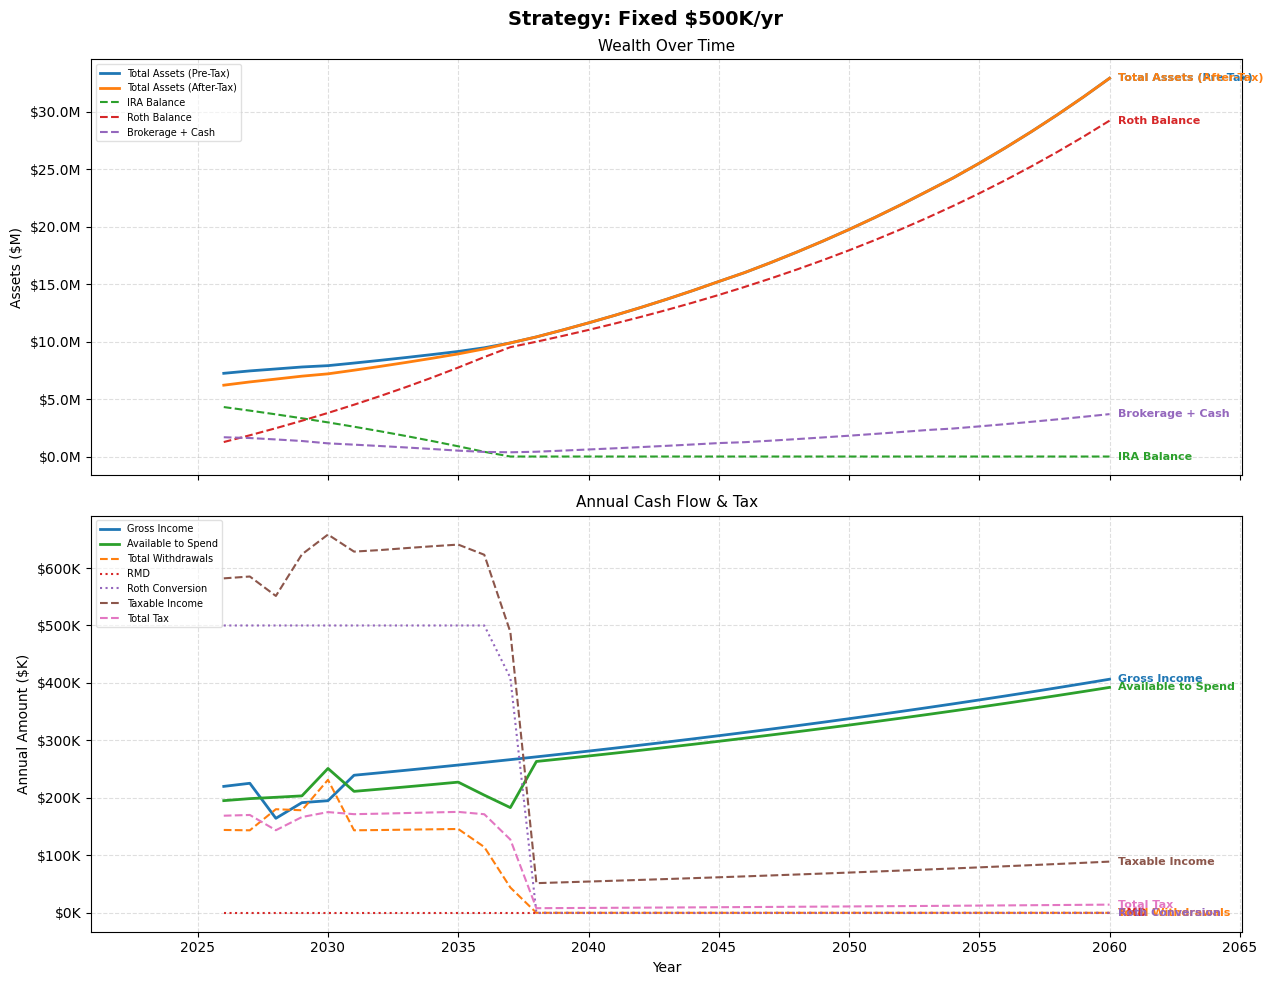

In [ ]:
# ============================================================
# Per-strategy 2-panel dashboards
# ============================================================

import matplotlib.ticker as mtick

def M(x): return x / 1_000_000
def K(x): return x / 1_000

def label_line(ax, years, values, label, color, offset=(6, 0), fontsize=8):
    """Add an inline label at the right end of a line."""
    ax.annotate(
        label,
        xy=(years.iloc[-1], values.iloc[-1]),
        xytext=(offset[0], offset[1]),
        textcoords='offset points',
        color=color,
        fontsize=fontsize,
        va='center',
        fontweight='bold',
    )

# Conventional display labels → colors
colors_wealth = {
    'Total Assets (Pre-Tax)':   '#1f77b4',
    'Total Assets (After-Tax)': '#ff7f0e',
    'IRA Balance':              '#2ca02c',
    'Roth Balance':             '#d62728',
    'Brokerage + Cash':         '#9467bd',
}

colors_cashflow = {
    'Gross Income':       '#1f77b4',
    'Available to Spend': '#2ca02c',
    'Total Withdrawals':  '#ff7f0e',
    'RMD':               '#d62728',
    'Roth Conversion':   '#9467bd',
    'Taxable Income':    '#8c564b',
    'Total Tax':         '#e377c2',
}

for name, df_s in dashboard_results.items():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
    fig.suptitle(f'Strategy: {name}', fontsize=14, fontweight='bold')

    years = df_s['year']

    # ── TOP PANEL: Wealth ($M) ──────────────────────────────────────────
    wealth_series = [
        (df_s['end_total'],                           'Total Assets (Pre-Tax)',   2.0, '-' ),
        (df_s['after_tax_total'],                     'Total Assets (After-Tax)', 2.0, '-' ),
        (df_s['end_traditional'],                     'IRA Balance',              1.5, '--'),
        (df_s['end_roth'],                            'Roth Balance',             1.5, '--'),
        (df_s['end_taxable'] + df_s['end_cash'],     'Brokerage + Cash',         1.5, '--'),
    ]

    for series, label, lw, ls in wealth_series:
        c = colors_wealth[label]
        ax1.plot(years, M(series), label=label, color=c, linewidth=lw, linestyle=ls)
        label_line(ax1, years, M(series), label, c)

    ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.1f}M'))
    ax1.set_ylabel('Assets ($M)')
    ax1.legend(loc='upper left', fontsize=7, framealpha=0.6)
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.set_title('Wealth Over Time', fontsize=11)
    ax1.margins(x=0.15)

    # ── BOTTOM PANEL: Annual Cash Flow ($K) ────────────────────────────
    cashflow_series = [
        (df_s['gross_nonportfolio_income'],
             'Gross Income',       2.0, '-' ),
        (df_s['total_available_to_spend'],
             'Available to Spend', 2.0, '-' ),
        (df_s['withdrawal_cash'] + df_s['withdrawal_taxable']
         + df_s['withdrawal_traditional_cash'] + df_s['withdrawal_roth'],
             'Total Withdrawals',  1.5, '--'),
        (df_s['rmd_required'],
             'RMD',               1.5, ':' ),
        (df_s['roth_conversion'],
             'Roth Conversion',   1.5, ':' ),
        (df_s['taxable_income'],
             'Taxable Income',    1.5, '--'),
        (df_s['total_tax'],
             'Total Tax',         1.5, '--'),
    ]

    for series, label, lw, ls in cashflow_series:
        c = colors_cashflow[label]
        ax2.plot(years, K(series), label=label, color=c, linewidth=lw, linestyle=ls)
        label_line(ax2, years, K(series), label, c)

    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
    ax2.set_ylabel('Annual Amount ($K)')
    ax2.set_xlabel('Year')
    ax2.legend(loc='upper left', fontsize=7, framealpha=0.6)
    ax2.grid(True, linestyle='--', alpha=0.4)
    ax2.set_title('Annual Cash Flow & Tax', fontsize=11)
    ax2.margins(x=0.15)

    plt.tight_layout()
    plt.show()
    print()


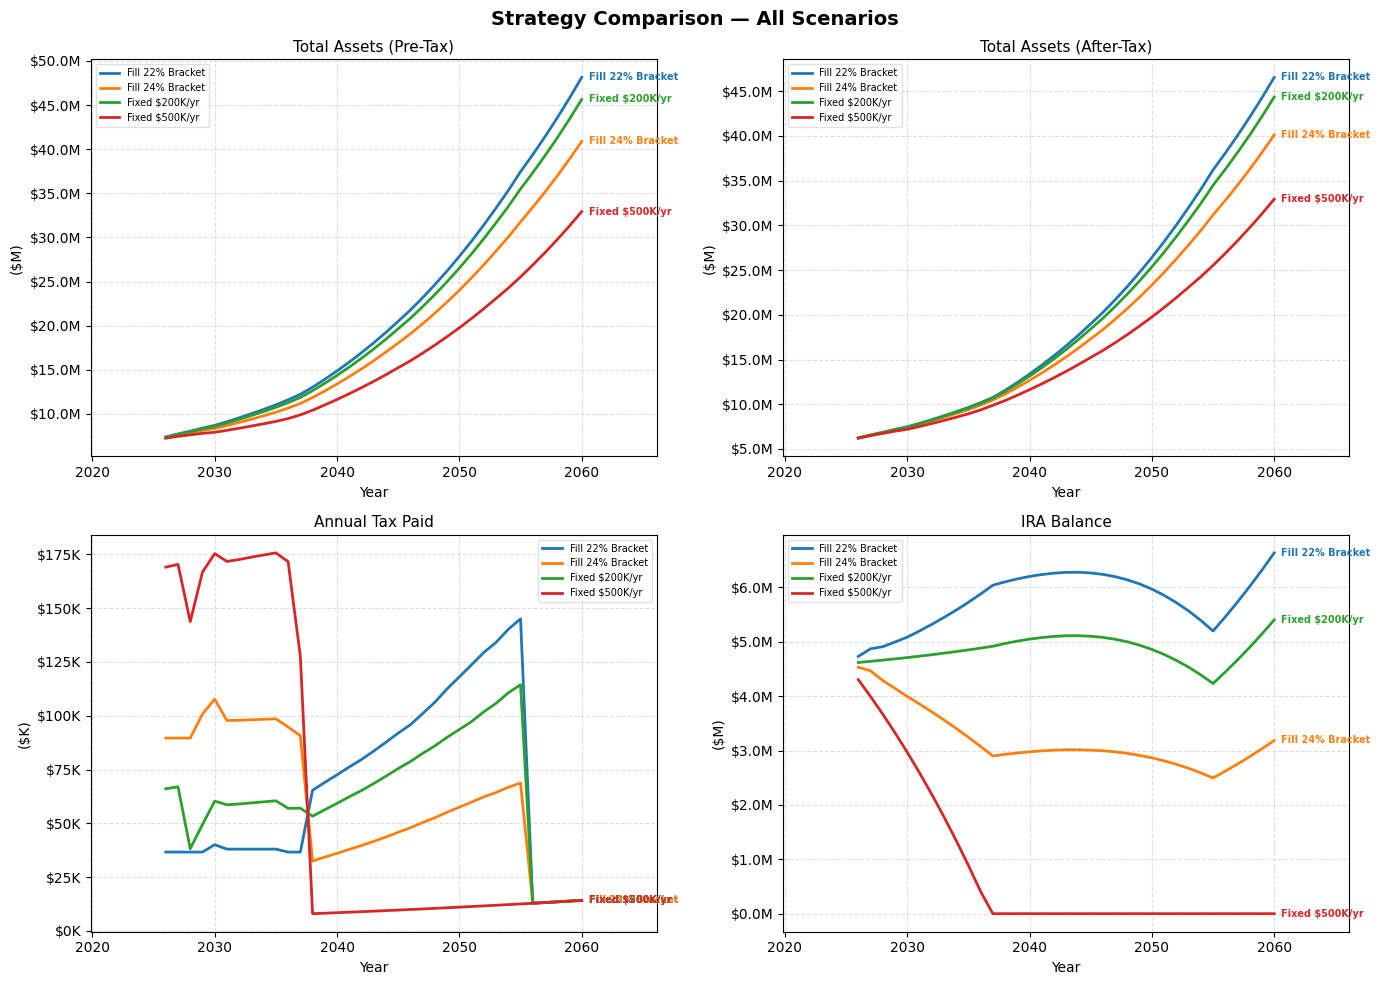


=== FINAL YEAR SUMMARY ===
                  Total Assets (Pre-Tax, $M)  Total Assets (After-Tax, $M)  IRA Balance ($M)  Roth Balance ($M)  Brokerage+Cash ($M)  Lifetime Tax ($M)  Total Roth Converted ($M)
Strategy                                                                                                                                                                          
Fill 22% Bracket                          48                            47                 7                 11                   31                  2                          2
Fill 24% Bracket                          41                            40                 3                 20                   17                  2                          4
Fixed $200K/yr                            46                            44                 5                 14                   26                  2                          2
Fixed $500K/yr                            33                            33   

In [ ]:
# ============================================================
# Comparison chart — all 4 strategies overlaid
# ============================================================

import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Strategy Comparison — All Scenarios', fontsize=14, fontweight='bold')

# strat_colors defined in dashboard sim cell above
ax_pretax   = axes[0, 0]
ax_aftertax = axes[0, 1]
ax_tax      = axes[1, 0]
ax_trad     = axes[1, 1]

for name, df_s in dashboard_results.items():
    c     = strat_colors[name]
    years = df_s['year']

    for ax, series, divisor in [
        (ax_pretax,   df_s['end_total'],        1e6),
        (ax_aftertax, df_s['after_tax_total'],   1e6),
        (ax_tax,      df_s['total_tax'],         1e3),
        (ax_trad,     df_s['end_traditional'],   1e6),
    ]:
        scaled = series / divisor
        ax.plot(years, scaled, label=name, color=c, linewidth=2)
        ax.annotate(
            name,
            xy=(years.iloc[-1], scaled.iloc[-1]),
            xytext=(5, 0),
            textcoords='offset points',
            color=c, fontsize=7,
            va='center', fontweight='bold',
        )

fmt_M = mtick.FuncFormatter(lambda x, _: f'${x:.1f}M')
fmt_K = mtick.FuncFormatter(lambda x, _: f'${x:.0f}K')

for ax, title, ylabel, fmt in [
    (ax_pretax,   'Total Assets (Pre-Tax)',    '($M)', fmt_M),
    (ax_aftertax, 'Total Assets (After-Tax)',   '($M)', fmt_M),
    (ax_tax,      'Annual Tax Paid',            '($K)', fmt_K),
    (ax_trad,     'IRA Balance',               '($M)', fmt_M),
]:
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(fmt)
    ax.legend(fontsize=7, framealpha=0.6)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.margins(x=0.18)

plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n=== FINAL YEAR SUMMARY ===")
summary_rows = []
for name, df_s in dashboard_results.items():
    last = df_s.iloc[-1]
    summary_rows.append({
        'Strategy':                   name,
        'Total Assets (Pre-Tax, $M)':  round(last['end_total']                        / 1e6, 2),
        'Total Assets (After-Tax, $M)':round(df_s['after_tax_total'].iloc[-1]         / 1e6, 2),
        'IRA Balance ($M)':            round(last['end_traditional']                  / 1e6, 2),
        'Roth Balance ($M)':           round(last['end_roth']                         / 1e6, 2),
        'Brokerage+Cash ($M)':         round((last['end_taxable']+last['end_cash'])   / 1e6, 2),
        'Lifetime Tax ($M)':           round(df_s['total_tax'].sum()                  / 1e6, 2),
        'Total Roth Converted ($M)':   round(df_s['roth_conversion'].sum()            / 1e6, 2),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Strategy')
print(summary_df.to_string())


## Year-by-Year Roth Conversion Table

How much is converted each year under each strategy.


In [ ]:
# ============================================================
# Year-by-year Roth Conversion, Income Levels & Tax
# by Strategy
#
# Income hierarchy:
#   Gross Non-Portfolio Income  = salary + rental + pension + SS (no RMD, no conversions)
#   Gross Ordinary Income       = above + RMD + IRA withdrawals + Roth conversion
#   Taxable Income              = Gross Ordinary + cap gains - standard deduction
# ============================================================

def fmt_currency(x):
    return f'${x:,.0f}'

years_list = dashboard_results[list(dashboard_results.keys())[0]]['year'].values

for name, df_s in dashboard_results.items():
    short = (name
             .replace('Fill ', 'F')
             .replace('% Bracket', '%')
             .replace('Fixed ', '')
             .replace('/yr', ''))

    rows = []
    for i, yr in enumerate(years_list):
        rows.append({
            'Year':                        int(yr),
            'Roth Conversion':             df_s['roth_conversion'].iloc[i],
            'RMD':                         df_s['rmd_required'].iloc[i],
            'Gross Non-Portfolio Income':  df_s['gross_nonportfolio_income'].iloc[i],
            'Gross Ordinary Income':       df_s['gross_ordinary_income'].iloc[i],
            'Taxable Income':              df_s['taxable_income'].iloc[i],
            'Total Tax':                   df_s['total_tax'].iloc[i],
        })

    tbl = pd.DataFrame(rows).set_index('Year')

    # Add summary rows
    tbl.loc['TOTAL']        = tbl.sum()
    tbl.loc['LIFETIME AVG'] = tbl.iloc[:-1].mean()

    print(f"{'='*70}")
    print(f"  Strategy: {name}")
    print(f"{'='*70}")
    print(tbl.applymap(fmt_currency).to_string())
    print()


  Strategy: Fill 22% Bracket
             Roth Conversion         RMD Gross Non-Portfolio Income Gross Ordinary Income Taxable Income   Total Tax
Year                                                                                                                
2026                 $94,700          $0                   $220,000              $206,700       $176,700     $36,654
2027                 $91,460          $0                   $225,400              $206,700       $176,700     $36,654
2028                $194,073          $0                   $164,448              $206,700       $176,700     $36,654
2029                $152,975          $0                   $191,737              $206,700       $176,700     $36,654
2030                $152,160          $0                   $195,092              $206,700       $194,247     $40,075
2031                $133,960          $0                   $239,384              $206,700       $183,738     $38,026
2032                $132,765       

/tmp/ipykernel_12448/1157002025.py:44: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(tbl.applymap(fmt_currency).to_string())
/tmp/ipykernel_12448/1157002025.py:44: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(tbl.applymap(fmt_currency).to_string())
/tmp/ipykernel_12448/1157002025.py:44: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(tbl.applymap(fmt_currency).to_string())
/tmp/ipykernel_12448/1157002025.py:44: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(tbl.applymap(fmt_currency).to_string())


Simulated: Fill 24% Bracket
Simulated: Fill to $500K
Simulated: Fill to $600K
Simulated: Fill to $700K
Simulated: Fixed $200K
Simulated: Fixed $500K

=== FILL BRACKET vs FIXED — FINAL YEAR SUMMARY ===

                  Pre-Tax Total ($M)  After-Tax Total ($M)  IRA Balance ($M)  Roth Balance ($M)  Lifetime Tax ($M)  Total Roth Conv ($M)
Strategy                                                                                                                                
Fill 24% Bracket                  41                    40                 3                 20                  2                     4
Fill to $500K                     36                    36                 1                 26                  2                     5
Fill to $600K                     33                    33                 0                 29                  2                     6
Fill to $700K                     32                    32                 0                 29                  

/tmp/ipykernel_12448/2229257164.py:95: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(conv_compare.applymap(lambda x: f'${x:,.0f}').to_string())


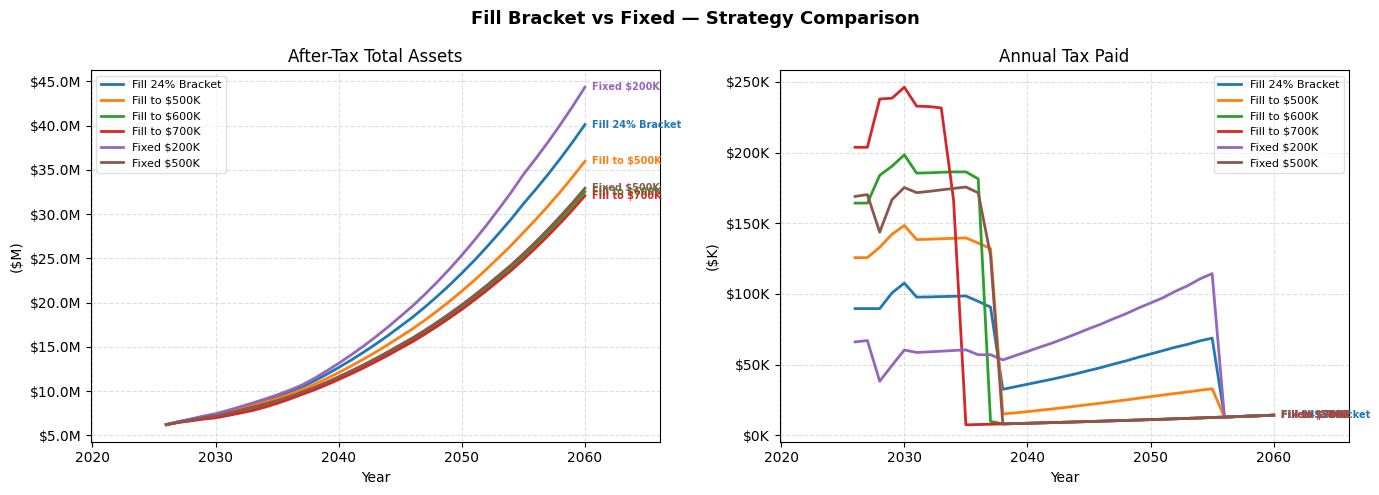

In [ ]:
# ============================================================
# Fill Bracket Comparison: 500K, 600K, 700K targets
# vs Fixed 500K for reference
# ============================================================

fill_strategies = {
    'Fill 24% Bracket': RothStrategy(
        strategy_type='fill_bracket',
        bracket_top=394600,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=True,
    ),
    'Fill to $500K': RothStrategy(
        strategy_type='fill_bracket',
        bracket_top=500000,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=True,
    ),
    'Fill to $600K': RothStrategy(
        strategy_type='fill_bracket',
        bracket_top=600000,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=True,
    ),
    'Fill to $700K': RothStrategy(
        strategy_type='fill_bracket',
        bracket_top=700000,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=True,
    ),
    'Fixed $200K': RothStrategy(
        strategy_type='fixed',
        fixed_amount=200000,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=True,
    ),
    'Fixed $500K': RothStrategy(
        strategy_type='fixed',
        fixed_amount=500000,
        start_year=CONV_START_YEAR,
        end_year=CONV_END_YEAR,
        stop_at_rmd=True,
    ),
}

# --- Run simulations ---
fill_results = {}
for name, strat in fill_strategies.items():
    sc = clone_scenario_with_roth_strategy(scenario, strat)
    df_s = run_simulation(sc)
    df_s['after_tax_total'] = (
        df_s['end_taxable']
        + df_s['end_roth']
        + df_s['end_traditional'] * (1 - HAIRCUT_RATE)
        + df_s['end_cash']
    )
    fill_results[name] = df_s
    print(f"Simulated: {name}")

# --- Summary table ---
print("\n=== FILL BRACKET vs FIXED — FINAL YEAR SUMMARY ===\n")
fill_summary = []
for name, df_s in fill_results.items():
    last = df_s.iloc[-1]
    fill_summary.append({
        'Strategy':               name,
        'Pre-Tax Total ($M)':     round(last['end_total']                       / 1e6, 2),
        'After-Tax Total ($M)':   round(df_s['after_tax_total'].iloc[-1]        / 1e6, 2),
        'IRA Balance ($M)':       round(last['end_traditional']                 / 1e6, 2),
        'Roth Balance ($M)':      round(last['end_roth']                        / 1e6, 2),
        'Lifetime Tax ($M)':      round(df_s['total_tax'].sum()                 / 1e6, 2),
        'Total Roth Conv ($M)':   round(df_s['roth_conversion'].sum()           / 1e6, 2),
    })

fill_summary_df = pd.DataFrame(fill_summary).set_index('Strategy')
print(fill_summary_df.to_string())

# --- Year-by-year conversion and tax comparison ---
print("\n=== YEAR-BY-YEAR: Roth Conversion & Tax Paid ===\n")
conv_compare = pd.DataFrame({'Year': fill_results['Fill to $500K']['year'].values})

for name, df_s in fill_results.items():
    short = name.replace('Fill to ', 'F').replace('Fixed ', 'Fx').replace(' (ref)', '')
    conv_compare[f'{short} Conv']     = df_s['roth_conversion'].values
    conv_compare[f'{short} Tax']      = df_s['total_tax'].values
    conv_compare[f'{short} GrossOrd'] = df_s['gross_ordinary_income'].values

conv_compare = conv_compare.set_index('Year')
conv_compare.loc['TOTAL'] = conv_compare.sum()
print(conv_compare.applymap(lambda x: f'${x:,.0f}').to_string())

# --- Chart: After-Tax Total Assets over time ---
import matplotlib.ticker as mtick

# Local colors for fill_results strategies
_fill_color_cycle = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
]
fill_colors = {
    name: _fill_color_cycle[i % len(_fill_color_cycle)]
    for i, name in enumerate(fill_results.keys())
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fill Bracket vs Fixed — Strategy Comparison', fontsize=13, fontweight='bold')

ax_after  = axes[0]
ax_tax    = axes[1]

fmt_M = mtick.FuncFormatter(lambda x, _: f'${x:.1f}M')
fmt_K = mtick.FuncFormatter(lambda x, _: f'${x:.0f}K')

for name, df_s in fill_results.items():
    c     = fill_colors[name]
    years = df_s['year']
    ax_after.plot(years, df_s['after_tax_total'] / 1e6, label=name, color=c, linewidth=2)
    ax_tax.plot(  years, df_s['total_tax']       / 1e3, label=name, color=c, linewidth=2)
    # Inline labels
    ax_after.annotate(name, xy=(years.iloc[-1], df_s['after_tax_total'].iloc[-1]/1e6),
                      xytext=(5,0), textcoords='offset points',
                      color=c, fontsize=7, va='center', fontweight='bold')
    ax_tax.annotate(name, xy=(years.iloc[-1], df_s['total_tax'].iloc[-1]/1e3),
                    xytext=(5,0), textcoords='offset points',
                    color=c, fontsize=7, va='center', fontweight='bold')

ax_after.set_title('After-Tax Total Assets')
ax_after.set_ylabel('($M)')
ax_after.set_xlabel('Year')
ax_after.yaxis.set_major_formatter(fmt_M)
ax_after.legend(fontsize=8, framealpha=0.6)
ax_after.grid(True, linestyle='--', alpha=0.4)
ax_after.margins(x=0.18)

ax_tax.set_title('Annual Tax Paid')
ax_tax.set_ylabel('($K)')
ax_tax.set_xlabel('Year')
ax_tax.yaxis.set_major_formatter(fmt_K)
ax_tax.legend(fontsize=8, framealpha=0.6)
ax_tax.grid(True, linestyle='--', alpha=0.4)
ax_tax.margins(x=0.18)

plt.tight_layout()
plt.show()

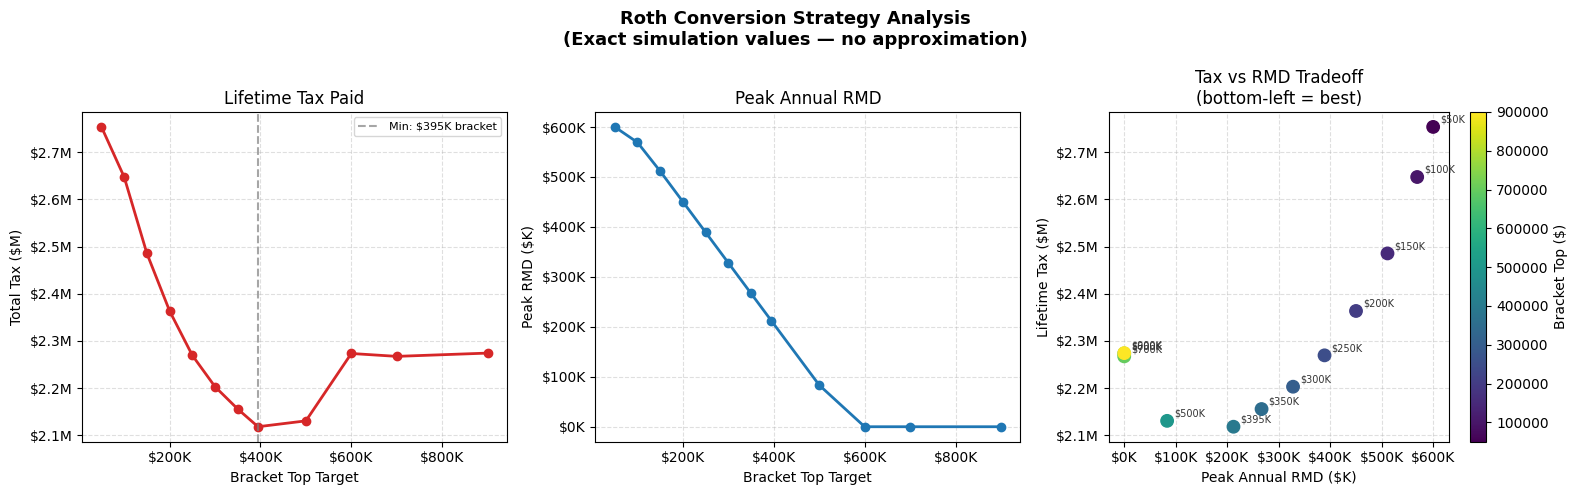


=== STRATEGY COMPARISON TABLE ===

Bracket Top Lifetime Tax Peak RMD Total Converted Final Taxable Final Cash  Final IRA  Final Roth Final Total
       $50K   $2,753,448 $600,193         $37,373   $38,745,878   $324,145 $9,008,339  $4,048,194 $52,126,557
      $100K   $2,647,325 $569,170        $343,980   $37,237,108   $324,145 $8,542,715  $5,350,046 $51,454,015
      $150K   $2,485,459 $511,491        $916,740   $34,304,334   $324,145 $7,677,006  $7,770,509 $50,075,995
      $200K   $2,363,524 $450,327      $1,516,740   $30,960,003   $324,145 $6,758,987 $10,337,226 $48,380,361
      $250K   $2,269,487 $389,163      $2,116,740   $27,469,607   $324,145 $5,840,968 $12,903,942 $46,538,662
      $300K   $2,203,044 $327,998      $2,716,740   $23,895,591   $324,145 $4,922,950 $15,470,658 $44,613,344
      $350K   $2,155,741 $266,834      $3,316,740   $20,282,598   $324,145 $4,004,931 $18,037,374 $42,649,048
      $395K   $2,118,256 $212,276      $3,851,940   $17,043,793   $324,145 $3,186,05

In [ ]:
# ============================================================
# Optimization by Lifetime Tax and Peak RMD
# No after-tax haircut approximation needed — exact simulation values
# ============================================================

import matplotlib.ticker as mtick

targets = [50000, 100000, 150000, 200000, 250000, 300000,
           350000, 394600, 500000, 600000, 700000, 900000]

sweep = evaluate_roth_targets(
    scenario,
    targets,
    start_year=CONV_START_YEAR,
    end_year=CONV_END_YEAR,
    stop_at_rmd=True,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Roth Conversion Strategy Analysis\n(Exact simulation values — no approximation)',
             fontsize=13, fontweight='bold')

fmt_M = mtick.FuncFormatter(lambda x, _: f'${x:.1f}M')
fmt_K = mtick.FuncFormatter(lambda x, _: f'${x:.0f}K')
fmt_xK = mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')

# ── Plot 1: Lifetime Tax by Bracket Target ──────────────────
ax1 = axes[0]
ax1.plot(sweep['bracket_top'], sweep['total_tax'] / 1e6,
         marker='o', color='#d62728', linewidth=2)
ax1.yaxis.set_major_formatter(fmt_M)
ax1.xaxis.set_major_formatter(fmt_xK)
ax1.set_title('Lifetime Tax Paid')
ax1.set_xlabel('Bracket Top Target')
ax1.set_ylabel('Total Tax ($M)')
ax1.grid(True, linestyle='--', alpha=0.4)

# Mark minimum
min_idx = sweep['total_tax'].idxmin()
ax1.axvline(sweep.loc[min_idx, 'bracket_top'],
            color='grey', linestyle='--', alpha=0.7,
            label=f"Min: ${sweep.loc[min_idx, 'bracket_top']/1000:.0f}K bracket")
ax1.legend(fontsize=8)

# ── Plot 2: Peak RMD by Bracket Target ─────────────────────
ax2 = axes[1]
ax2.plot(sweep['bracket_top'], sweep['max_rmd'] / 1e3,
         marker='o', color='#1f77b4', linewidth=2)
ax2.yaxis.set_major_formatter(fmt_K)
ax2.xaxis.set_major_formatter(fmt_xK)
ax2.set_title('Peak Annual RMD')
ax2.set_xlabel('Bracket Top Target')
ax2.set_ylabel('Peak RMD ($K)')
ax2.grid(True, linestyle='--', alpha=0.4)

# ── Plot 3: Lifetime Tax vs Peak RMD (tradeoff scatter) ────
ax3 = axes[2]
sc = ax3.scatter(sweep['max_rmd'] / 1e3, sweep['total_tax'] / 1e6,
                 c=sweep['bracket_top'], cmap='viridis',
                 s=80, zorder=5)

# Label each dot with bracket target
for _, row in sweep.iterrows():
    ax3.annotate(
        f"${row['bracket_top']/1000:.0f}K",
        xy=(row['max_rmd']/1e3, row['total_tax']/1e6),
        xytext=(5, 3), textcoords='offset points',
        fontsize=7, color='#333333'
    )

ax3.yaxis.set_major_formatter(fmt_M)
ax3.xaxis.set_major_formatter(fmt_K)
ax3.set_title('Tax vs RMD Tradeoff\n(bottom-left = best)')
ax3.set_xlabel('Peak Annual RMD ($K)')
ax3.set_ylabel('Lifetime Tax ($M)')
ax3.grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc, ax=ax3, label='Bracket Top ($)')

plt.tight_layout()
plt.show()

# ── Enhanced Summary table ──────────────────────────────────
print("\n=== STRATEGY COMPARISON TABLE ===\n")

display_cols = sweep[[
    'bracket_top',
    'total_tax',
    'max_rmd',
    'total_roth_conversion',
    'final_taxable',
    'final_cash',
    'ending_traditional_balance',
    'ending_roth_balance',
    'final_total_assets',
]].copy()

display_cols.columns = [
    'Bracket Top',
    'Lifetime Tax',
    'Peak RMD',
    'Total Converted',
    'Final Taxable',
    'Final Cash',
    'Final IRA',
    'Final Roth',
    'Final Total',
]

display_cols['Bracket Top'] = display_cols['Bracket Top'].apply(
    lambda x: f'${x/1000:.0f}K')

for col in ['Lifetime Tax', 'Peak RMD', 'Total Converted',
            'Final Taxable', 'Final Cash', 'Final IRA',
            'Final Roth', 'Final Total']:
    display_cols[col] = display_cols[col].apply(lambda x: f'${x:,.0f}')

print(display_cols.to_string(index=False))

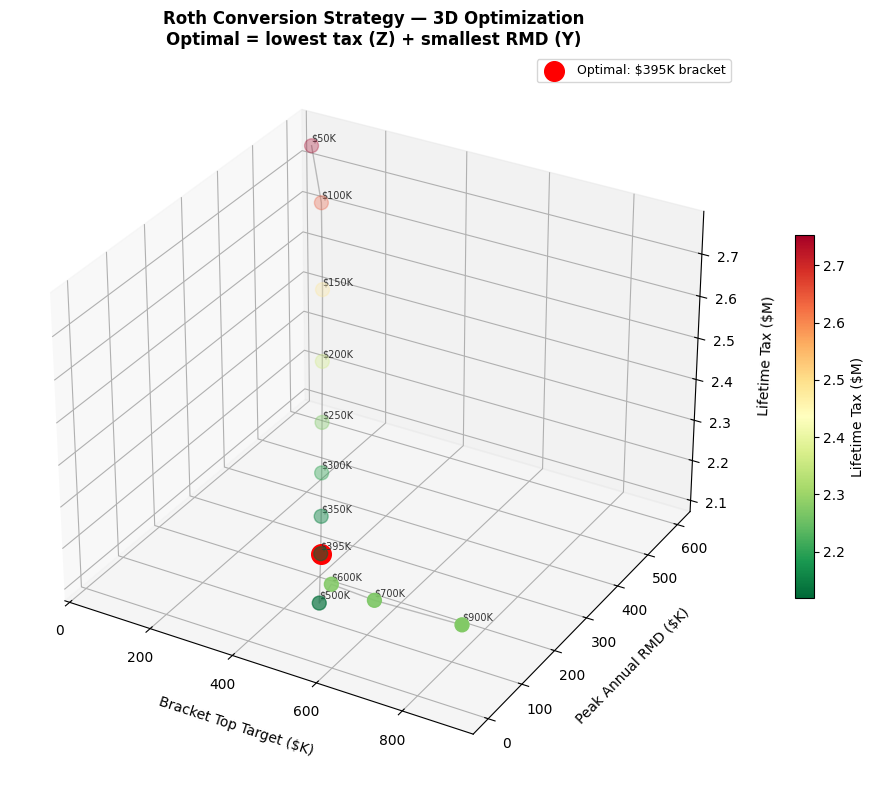

In [ ]:
# ============================================================
# 3D Strategy Visualization
# X = Bracket Top, Y = Peak RMD, Z = Lifetime Tax
# Optimal = lowest Z, smallest Y
# ============================================================

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as mtick
import numpy as np

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

x = sweep['bracket_top'] / 1000        # Bracket Top ($K)
y = sweep['max_rmd'] / 1000            # Peak RMD ($K)
z = sweep['total_tax'] / 1e6          # Lifetime Tax ($M)

# Plot the line connecting all strategies
ax.plot(x, y, z, color='grey', linewidth=1, alpha=0.5)

# Plot each strategy as a colored dot
sc = ax.scatter(x, y, z, c=z, cmap='RdYlGn_r', s=100, zorder=5)

# Label each point
for i, row in sweep.iterrows():
    ax.text(
        row['bracket_top']/1000,
        row['max_rmd']/1000,
        row['total_tax']/1e6 + 0.01,
        f"${row['bracket_top']/1000:.0f}K",
        fontsize=7,
        color='#333333'
    )

# Mark the optimal point (minimum lifetime tax)
min_idx = sweep['total_tax'].idxmin()
best = sweep.loc[min_idx]
ax.scatter(
    [best['bracket_top']/1000],
    [best['max_rmd']/1000],
    [best['total_tax']/1e6],
    color='red', s=200, zorder=10,
    label=f"Optimal: ${best['bracket_top']/1000:.0f}K bracket"
)

ax.set_xlabel('Bracket Top Target ($K)', labelpad=10)
ax.set_ylabel('Peak Annual RMD ($K)', labelpad=10)
ax.set_zlabel('Lifetime Tax ($M)', labelpad=10)
ax.set_title('Roth Conversion Strategy — 3D Optimization\n'
             'Optimal = lowest tax (Z) + smallest RMD (Y)',
             fontsize=12, fontweight='bold')

ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label='Lifetime Tax ($M)', shrink=0.5)

plt.tight_layout()
plt.show()

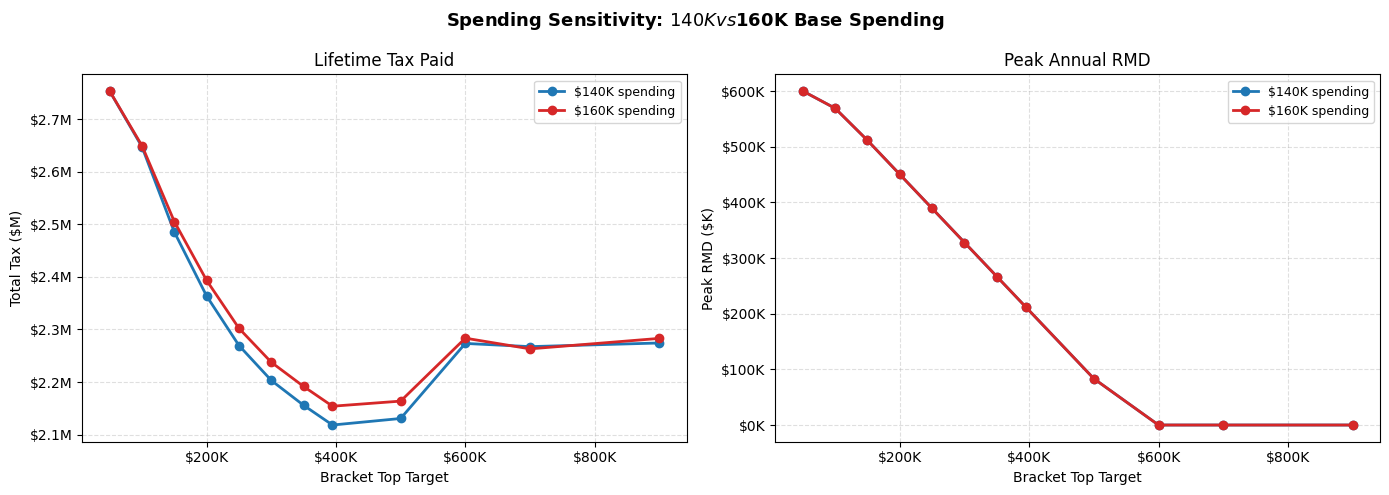


=== $140K vs $160K SPENDING — KEY METRICS AT $395K BRACKET ===

Metric                               $140K Spending       $160K Spending
------------------------------------------------------------------------
Lifetime Tax                   $M              2.12 $M              2.15
Peak RMD                       $K            212.28 $K            212.28
Total Converted                $M              3.85 $M              3.85
Final IRA Balance              $M              3.19 $M              3.19
Final Roth Balance             $M             20.33 $M             20.33
Final Total Assets             $M             40.88 $M             37.99


In [ ]:
# ============================================================
# Spending Sensitivity: $140K vs $160K base spending
# ============================================================

import copy

# Clone scenario with $160K spending
scenario_160k = copy.deepcopy(scenario)
scenario_160k.spending.base_spending = 160000

# Run the same bracket sweep with $160K spending
sweep_160k = evaluate_roth_targets(
    scenario_160k,
    targets,
    start_year=2026,
    end_year=2037,
    stop_at_rmd=True,
)

# Compare side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Spending Sensitivity: $140K vs $160K Base Spending',
             fontsize=13, fontweight='bold')

fmt_M = mtick.FuncFormatter(lambda x, _: f'${x:.1f}M')
fmt_xK = mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')

# Lifetime Tax
ax1 = axes[0]
ax1.plot(sweep['bracket_top'], sweep['total_tax'] / 1e6,
         marker='o', color='#1f77b4', linewidth=2, label='$140K spending')
ax1.plot(sweep_160k['bracket_top'], sweep_160k['total_tax'] / 1e6,
         marker='o', color='#d62728', linewidth=2, label='$160K spending')
ax1.yaxis.set_major_formatter(fmt_M)
ax1.xaxis.set_major_formatter(fmt_xK)
ax1.set_title('Lifetime Tax Paid')
ax1.set_xlabel('Bracket Top Target')
ax1.set_ylabel('Total Tax ($M)')
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# Peak RMD
ax2 = axes[1]
ax2.plot(sweep['bracket_top'], sweep['max_rmd'] / 1e3,
         marker='o', color='#1f77b4', linewidth=2, label='$140K spending')
ax2.plot(sweep_160k['bracket_top'], sweep_160k['max_rmd'] / 1e3,
         marker='o', color='#d62728', linewidth=2, label='$160K spending')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax2.xaxis.set_major_formatter(fmt_xK)
ax2.set_title('Peak Annual RMD')
ax2.set_xlabel('Bracket Top Target')
ax2.set_ylabel('Peak RMD ($K)')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Comparison table
print("\n=== $140K vs $160K SPENDING — KEY METRICS AT $395K BRACKET ===\n")
row_140 = sweep[sweep['bracket_top'] == 394600].iloc[0]
row_160 = sweep_160k[sweep_160k['bracket_top'] == 394600].iloc[0]

print(f"{'Metric':<30} {'$140K Spending':>20} {'$160K Spending':>20}")
print("-" * 72)
for label, key, div in [
    ('Lifetime Tax',        'total_tax',                   1e6),
    ('Peak RMD',            'max_rmd',                     1e3),
    ('Total Converted',     'total_roth_conversion',       1e6),
    ('Final IRA Balance',   'ending_traditional_balance',  1e6),
    ('Final Roth Balance',  'ending_roth_balance',         1e6),
    ('Final Total Assets',  'final_total_assets',          1e6),
]:
    v140 = row_140[key] / div
    v160 = row_160[key] / div
    unit = '$M' if div == 1e6 else '$K'
    print(f"{label:<30} {unit}{v140:>18,.2f} {unit}{v160:>18,.2f}")

Simulated end year 2045
Simulated end year 2050
Simulated end year 2055
Simulated end year 2060
Simulated end year 2065


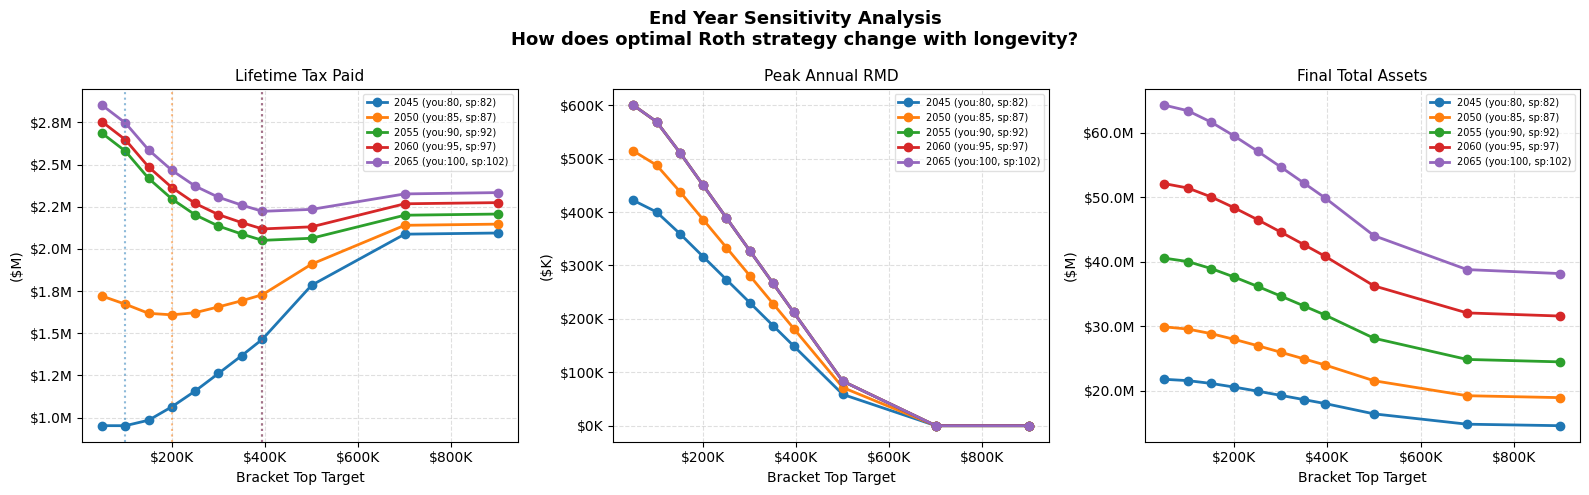


=== OPTIMAL BRACKET BY END YEAR ===

End Year   Your Age   Spouse Age   Optimal Bracket    Min Lifetime Tax     Peak RMD     Final Assets
-----------------------------------------------------------------------------------------------
2045       80         82           $100K              $       951,702      $ 400,162   $    21,584,865
2050       85         87           $200K              $     1,608,944      $ 386,031   $    27,979,357
2055       90         92           $395K              $     2,050,508      $ 212,276   $    31,762,990
2060       95         97           $395K              $     2,118,256      $ 212,276   $    40,880,881
2065       100        102          $395K              $     2,222,590      $ 212,276   $    49,932,632


In [ ]:
# ============================================================
# End Year Sensitivity Analysis
# How does the optimal strategy change based on how long you live?
# ============================================================

import matplotlib.ticker as mtick

# End years to test — corresponds roughly to ages:
# 2045 = you: 80, spouse: 82
# 2050 = you: 85, spouse: 87
# 2055 = you: 90, spouse: 92
# 2060 = you: 95, spouse: 97
# 2065 = you: 100, spouse: 102

end_years_to_test = [2045, 2050, 2055, 2060, 2065]

# Bracket targets to test for each end year
bracket_targets = BRACKET_TARGETS

end_year_results = {}

for end_yr in end_years_to_test:
    # Clone scenario with different end year
    import copy
    sc_ey = copy.deepcopy(scenario)
    sc_ey.simulation.end_year = end_yr

    sweep_ey = evaluate_roth_targets(
        sc_ey,
        bracket_targets,
        start_year  = CONV_START_YEAR,
        end_year    = CONV_END_YEAR,
        stop_at_rmd = CONV_STOP_AT_RMD,
    )
    end_year_results[end_yr] = sweep_ey
    print(f"Simulated end year {end_yr}")

# ── Plot 1: Lifetime Tax by Bracket Target for each End Year ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('End Year Sensitivity Analysis\n'
             'How does optimal Roth strategy change with longevity?',
             fontsize=13, fontweight='bold')

fmt_M  = mtick.FuncFormatter(lambda x, _: f'${x:.1f}M')
fmt_xK = mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
fmt_K  = mtick.FuncFormatter(lambda x, _: f'${x:.0f}K')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

ax1, ax2, ax3 = axes[0], axes[1], axes[2]

for (end_yr, sweep_ey), color in zip(end_year_results.items(), colors):
    you_age    = end_yr - scenario.you.birth_year
    spouse_age = end_yr - scenario.spouse.birth_year
    label = f"{end_yr} (you:{you_age}, sp:{spouse_age})"

    ax1.plot(sweep_ey['bracket_top'], sweep_ey['total_tax'] / 1e6,
             marker='o', color=color, linewidth=2, label=label)

    ax2.plot(sweep_ey['bracket_top'], sweep_ey['max_rmd'] / 1e3,
             marker='o', color=color, linewidth=2, label=label)

    ax3.plot(sweep_ey['bracket_top'], sweep_ey['final_total_assets'] / 1e6,
             marker='o', color=color, linewidth=2, label=label)

# Format axes
for ax, title, ylabel, fmt in [
    (ax1, 'Lifetime Tax Paid',    '($M)', fmt_M),
    (ax2, 'Peak Annual RMD',      '($K)', fmt_K),
    (ax3, 'Final Total Assets',   '($M)', fmt_M),
]:
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Bracket Top Target')
    ax.yaxis.set_major_formatter(fmt)
    ax.xaxis.set_major_formatter(fmt_xK)
    ax.legend(fontsize=7, framealpha=0.6)
    ax.grid(True, linestyle='--', alpha=0.4)

    # Mark minimum tax point for each end year
    if ax == ax1:
        for (end_yr, sweep_ey), color in zip(end_year_results.items(), colors):
            min_idx = sweep_ey['total_tax'].idxmin()
            ax.axvline(sweep_ey.loc[min_idx, 'bracket_top'],
                      color=color, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Summary table: optimal bracket by end year ────────────────────────────
print("\n=== OPTIMAL BRACKET BY END YEAR ===\n")
print(f"{'End Year':<10} {'Your Age':<10} {'Spouse Age':<12} "
      f"{'Optimal Bracket':<18} {'Min Lifetime Tax':<20} {'Peak RMD':<12} {'Final Assets'}")
print("-" * 95)

for end_yr, sweep_ey in end_year_results.items():
    you_age    = end_yr - scenario.you.birth_year
    spouse_age = end_yr - scenario.spouse.birth_year
    min_idx    = sweep_ey['total_tax'].idxmin()
    opt_row    = sweep_ey.loc[min_idx]
    print(f"{end_yr:<10} {you_age:<10} {spouse_age:<12} "
          f"${opt_row['bracket_top']/1000:.0f}K{'':<13} "
          f"${opt_row['total_tax']:>14,.0f}      "
          f"${opt_row['max_rmd']:>8,.0f}   "
          f"${opt_row['final_total_assets']:>14,.0f}")

Simulated: No Conversion
Simulated: Fill 22% Bracket
Simulated: Fill 24% Bracket
Simulated: Fixed $200K/yr

=== ESTATE VALUE TO HEIRS ===
Assumptions: Heir IRA tax rate = 32%, Taxable gets step-up in basis at death

Strategy                    Taxable         Roth    IRA (after tax)         Cash   Total to Heirs   Heir Tax Cost
-----------------------------------------------------------------------------------------------------------------
No Conversion          $38,947,133 $ 3,861,211 $       6,171,147 $   324,145 $    49,303,636 $    2,904,069
Fill 22% Bracket       $30,496,011 $10,681,166 $       4,512,461 $   324,145 $    46,013,783 $    2,123,511
Fill 24% Bracket       $17,043,793 $20,326,885 $       2,166,520 $   324,145 $    39,861,342 $    1,019,539
Fixed $200K/yr         $25,785,492 $14,128,076 $       3,674,136 $   324,145 $    43,911,849 $    1,729,005


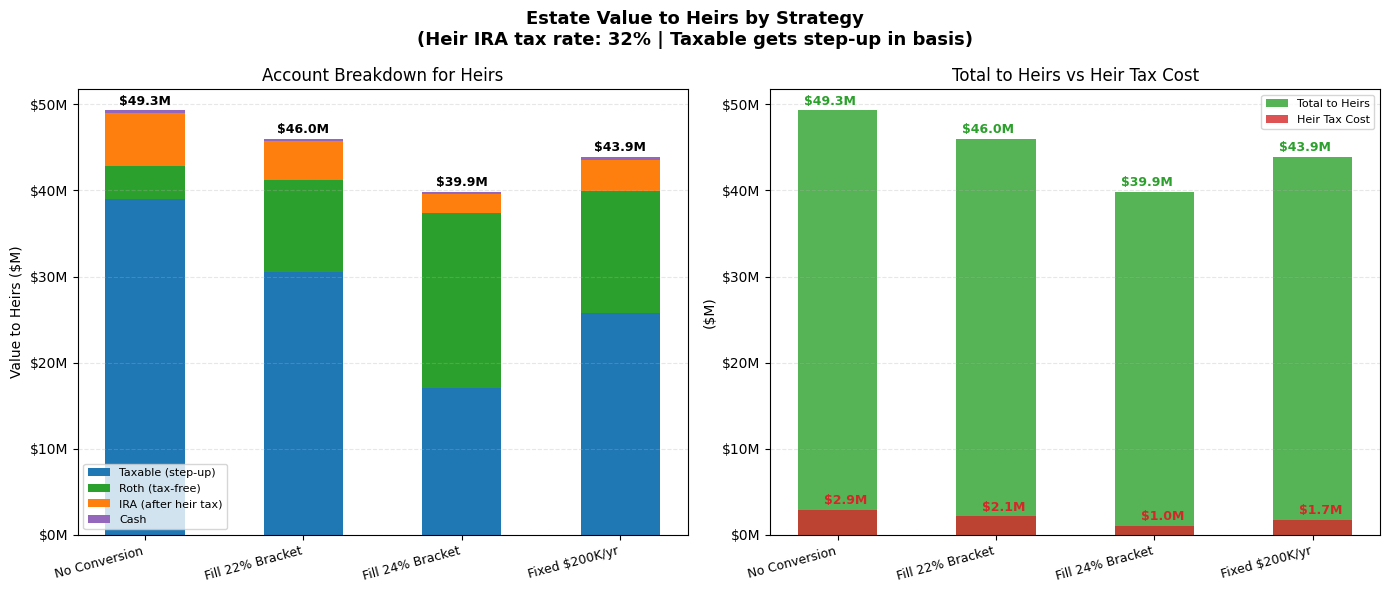


=== SENSITIVITY TO HEIR TAX RATE ===
Heir Rate          No Conversion    Fill 22% Bracket    Fill 24% Bracket      Fixed $200K/yr
--------------------------------------------------------------------------------------------
22%         $              50.2M$              46.7M$              40.2M$              44.5M
24%         $              50.0M$              46.5M$              40.1M$              44.3M
32%         $              49.3M$              46.0M$              39.9M$              43.9M
35%         $              49.0M$              45.8M$              39.8M$              43.7M
37%         $              48.8M$              45.7M$              39.7M$              43.6M


In [ ]:
# ============================================================
# Estate Value Comparison
# Shows value of each account type to heirs AFTER their taxes
# ============================================================

import matplotlib.ticker as mtick
import copy

# ── Assumptions ──────────────────────────────────────────────────────────
# Heir's marginal tax rate on inherited traditional IRA distributions
# Under SECURE 2.0, heirs must distribute inherited IRA within 10 years
# If heirs are in their peak earning years, rate could be 32-37%
HEIR_ORDINARY_RATE   = 0.32   # ← heir's marginal rate on IRA withdrawals
HEIR_CAP_GAINS_RATE  = 0.15   # ← heir's long-term capital gains rate
#                                  (taxable brokerage gets step-up in basis
#                                   at death — gains are wiped out)

# ── Strategies to compare ────────────────────────────────────────────────
estate_strategies = {
    'No Conversion': RothStrategy(strategy_type='none'),
    'Fill 22% Bracket': RothStrategy(
        strategy_type='fill_bracket', bracket_top=DASHBOARD_BRACKET_22,
        start_year=CONV_START_YEAR, end_year=CONV_END_YEAR,
        stop_at_rmd=CONV_STOP_AT_RMD,
    ),
    'Fill 24% Bracket': RothStrategy(
        strategy_type='fill_bracket', bracket_top=DASHBOARD_BRACKET_24,
        start_year=CONV_START_YEAR, end_year=CONV_END_YEAR,
        stop_at_rmd=CONV_STOP_AT_RMD,
    ),
    'Fixed $200K/yr': RothStrategy(
        strategy_type='fixed', fixed_amount=DASHBOARD_FIXED_1,
        start_year=CONV_START_YEAR, end_year=CONV_END_YEAR,
        stop_at_rmd=CONV_STOP_AT_RMD,
    ),
}

# ── Run simulations ───────────────────────────────────────────────────────
estate_results = {}
for name, strat in estate_strategies.items():
    sc = clone_scenario_with_roth_strategy(scenario, strat)
    df_s = run_simulation(sc)
    estate_results[name] = df_s
    print(f"Simulated: {name}")

# ── Compute estate values ─────────────────────────────────────────────────
def compute_estate_value(df, heir_ordinary_rate, heir_cap_gains_rate):
    """
    Compute after-heir-tax value of each account type.

    Taxable brokerage:
        Heirs get step-up in basis at death — all embedded gains wiped out.
        Only NEW gains after inheritance are taxable.
        For simplicity: treat as fully after-tax (no haircut).

    Traditional IRA:
        Heirs must withdraw within 10 years under SECURE 2.0.
        Taxed at heir's ordinary income rate.
        Haircut = heir_ordinary_rate applied to full balance.

    Roth IRA:
        Fully tax-free to heirs. No haircut.

    Cash:
        Already after-tax. No haircut.
    """
    last = df.iloc[-1]

    val_taxable     = last['end_taxable']                              # step-up wipes gains
    val_roth        = last['end_roth']                                 # tax free
    val_traditional = last['end_traditional'] * (1 - heir_ordinary_rate)  # taxed at heir rate
    val_cash        = last['end_cash']                                 # after tax

    total_to_heirs  = val_taxable + val_roth + val_traditional + val_cash
    total_pretax    = last['end_total']
    tax_cost_heirs  = last['end_traditional'] * heir_ordinary_rate

    return {
        'Taxable Brokerage (step-up)': val_taxable,
        'Roth IRA (tax-free)':         val_roth,
        'Traditional IRA (after heir tax)': val_traditional,
        'Cash':                        val_cash,
        'Total to Heirs':              total_to_heirs,
        'Pre-Tax Total':               total_pretax,
        'Heir Tax Cost':               tax_cost_heirs,
        'Heir Tax Rate on IRA':        heir_ordinary_rate,
    }

estate_summary = {}
for name, df_s in estate_results.items():
    estate_summary[name] = compute_estate_value(
        df_s, HEIR_ORDINARY_RATE, HEIR_CAP_GAINS_RATE
    )

# ── Print summary table ───────────────────────────────────────────────────
print(f"\n=== ESTATE VALUE TO HEIRS ===")
print(f"Assumptions: Heir IRA tax rate = {HEIR_ORDINARY_RATE:.0%}, "
      f"Taxable gets step-up in basis at death\n")

headers = ['Strategy', 'Taxable', 'Roth', 'IRA (after tax)',
           'Cash', 'Total to Heirs', 'Heir Tax Cost']
print(f"{'Strategy':<22} {'Taxable':>12} {'Roth':>12} "
      f"{'IRA (after tax)':>18} {'Cash':>12} "
      f"{'Total to Heirs':>16} {'Heir Tax Cost':>15}")
print("-" * 113)

for name, vals in estate_summary.items():
    print(f"{name:<22} "
          f"${vals['Taxable Brokerage (step-up)']:>10,.0f} "
          f"${vals['Roth IRA (tax-free)']:>10,.0f} "
          f"${vals['Traditional IRA (after heir tax)']:>16,.0f} "
          f"${vals['Cash']:>10,.0f} "
          f"${vals['Total to Heirs']:>14,.0f} "
          f"${vals['Heir Tax Cost']:>13,.0f}")

# ── Bar chart: Total to Heirs by strategy ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Estate Value to Heirs by Strategy\n'
             f'(Heir IRA tax rate: {HEIR_ORDINARY_RATE:.0%} | '
             f'Taxable gets step-up in basis)',
             fontsize=13, fontweight='bold')

fmt_M = mtick.FuncFormatter(lambda x, _: f'${x:.0f}M')

strategy_names = list(estate_summary.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# ── Plot 1: Stacked bar — breakdown by account type ──────────────────────
ax1 = axes[0]
x = range(len(strategy_names))
width = 0.5

taxable_vals = [estate_summary[n]['Taxable Brokerage (step-up)'] / 1e6 for n in strategy_names]
roth_vals    = [estate_summary[n]['Roth IRA (tax-free)']         / 1e6 for n in strategy_names]
ira_vals     = [estate_summary[n]['Traditional IRA (after heir tax)'] / 1e6 for n in strategy_names]
cash_vals    = [estate_summary[n]['Cash']                        / 1e6 for n in strategy_names]

bars1 = ax1.bar(x, taxable_vals, width, label='Taxable (step-up)',  color='#1f77b4')
bars2 = ax1.bar(x, roth_vals,    width, bottom=taxable_vals,        label='Roth (tax-free)', color='#2ca02c')
bars3 = ax1.bar(x, ira_vals,     width,
                bottom=[t+r for t,r in zip(taxable_vals, roth_vals)],
                label='IRA (after heir tax)', color='#ff7f0e')
bars4 = ax1.bar(x, cash_vals,    width,
                bottom=[t+r+i for t,r,i in zip(taxable_vals, roth_vals, ira_vals)],
                label='Cash', color='#9467bd')

ax1.set_xticks(x)
ax1.set_xticklabels(strategy_names, rotation=15, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(fmt_M)
ax1.set_ylabel('Value to Heirs ($M)')
ax1.set_title('Account Breakdown for Heirs')
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add total labels on top of bars
for i, name in enumerate(strategy_names):
    total = estate_summary[name]['Total to Heirs'] / 1e6
    ax1.text(i, total + 0.3, f'${total:.1f}M',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Plot 2: Heir tax cost comparison ─────────────────────────────────────
ax2 = axes[1]
heir_tax_vals  = [estate_summary[n]['Heir Tax Cost']  / 1e6 for n in strategy_names]
total_vals     = [estate_summary[n]['Total to Heirs'] / 1e6 for n in strategy_names]

bars_heirs = ax2.bar(x, total_vals,    width, label='Total to Heirs', color='#2ca02c', alpha=0.8)
bars_tax   = ax2.bar(x, heir_tax_vals, width, label='Heir Tax Cost',  color='#d62728', alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(strategy_names, rotation=15, ha='right', fontsize=9)
ax2.yaxis.set_major_formatter(fmt_M)
ax2.set_ylabel('($M)')
ax2.set_title('Total to Heirs vs Heir Tax Cost')
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add labels
for i, (heirs, tax) in enumerate(zip(total_vals, heir_tax_vals)):
    ax2.text(i - 0.05, heirs + 0.3, f'${heirs:.1f}M',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2ca02c')
    ax2.text(i + 0.05, tax + 0.3,   f'${tax:.1f}M',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#d62728')

plt.tight_layout()
plt.show()

# ── Sensitivity: how does heir tax rate affect the conclusion? ────────────
print(f"\n=== SENSITIVITY TO HEIR TAX RATE ===")
print(f"{'Heir Rate':<12}", end='')
for name in strategy_names:
    print(f"{name:>20}", end='')
print()
print("-" * (12 + 20 * len(strategy_names)))

for heir_rate in [0.22, 0.24, 0.32, 0.35, 0.37]:
    print(f"{heir_rate:<12.0%}", end='')
    for name, df_s in estate_results.items():
        vals = compute_estate_value(df_s, heir_rate, HEIR_CAP_GAINS_RATE)
        print(f"${vals['Total to Heirs']/1e6:>18.1f}M", end='')
    print()

Simulated end year 2045
Simulated end year 2050
Simulated end year 2055
Simulated end year 2060
Simulated end year 2065


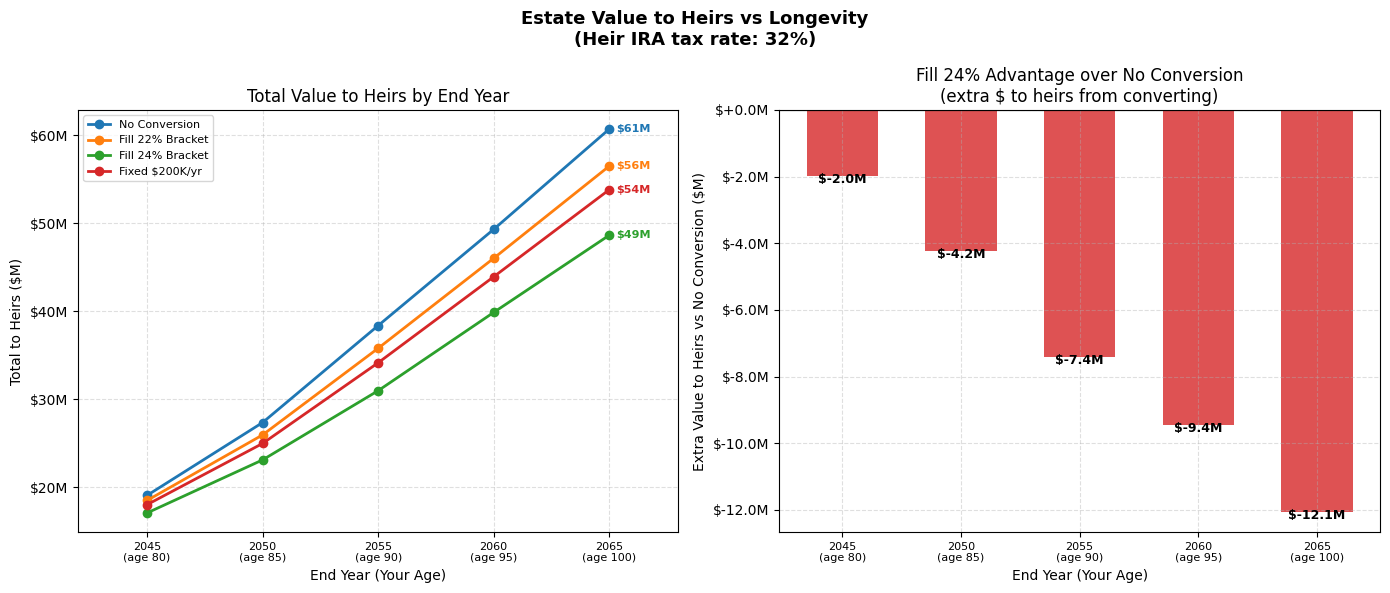


=== TOTAL VALUE TO HEIRS BY END YEAR & STRATEGY ===
(Heir IRA tax rate: 32%)

End Year   Your Age         No Conversion    Fill 22% Bracket    Fill 24% Bracket      Fixed $200K/yr  Best Strategy
-------------------------------------------------------------------------------------------------------------------
2045       80        $              19.1M$              18.5M$              17.1M$              18.0M  No Conversion
2050       85        $              27.3M$              25.9M$              23.1M$              25.0M  No Conversion
2055       90        $              38.4M$              35.8M$              31.0M$              34.1M  No Conversion
2060       95        $              49.3M$              46.0M$              39.9M$              43.9M  No Conversion
2065       100       $              60.7M$              56.5M$              48.6M$              53.8M  No Conversion


In [ ]:
# ============================================================
# Estate Value vs Longevity
# How does value to heirs change with end year for each strategy?
# ============================================================

import matplotlib.ticker as mtick
import copy

end_years_estate = [2045, 2050, 2055, 2060, 2065]

# Store results: {end_year: {strategy: estate_values}}
longevity_estate = {}

for end_yr in end_years_estate:
    longevity_estate[end_yr] = {}
    for name, strat in estate_strategies.items():
        sc = copy.deepcopy(scenario)
        sc.simulation.end_year = end_yr
        sc = clone_scenario_with_roth_strategy(sc, strat)
        df_s = run_simulation(sc)
        longevity_estate[end_yr][name] = compute_estate_value(
            df_s, HEIR_ORDINARY_RATE, HEIR_CAP_GAINS_RATE
        )
    print(f"Simulated end year {end_yr}")

# ── Plot: Total to Heirs by End Year for each Strategy ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Estate Value to Heirs vs Longevity\n'
             f'(Heir IRA tax rate: {HEIR_ORDINARY_RATE:.0%})',
             fontsize=13, fontweight='bold')

fmt_M  = mtick.FuncFormatter(lambda x, _: f'${x:.0f}M')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

ax1, ax2 = axes[0], axes[1]

# Plot 1: Total to heirs by end year
for (name, color) in zip(estate_strategies.keys(), colors):
    totals = [longevity_estate[yr][name]['Total to Heirs'] / 1e6
              for yr in end_years_estate]
    ages   = [yr - scenario.you.birth_year for yr in end_years_estate]
    labels = [f"{yr}\n(age {a})" for yr, a in zip(end_years_estate, ages)]
    ax1.plot(end_years_estate, totals, marker='o', color=color,
             linewidth=2, label=name)
    ax1.annotate(f'${totals[-1]:.0f}M',
                 xy=(end_years_estate[-1], totals[-1]),
                 xytext=(5, 0), textcoords='offset points',
                 color=color, fontsize=8, fontweight='bold', va='center')

ax1.set_xticks(end_years_estate)
ax1.set_xticklabels([f"{yr}\n(age {yr - scenario.you.birth_year})"
                     for yr in end_years_estate], fontsize=8)
ax1.yaxis.set_major_formatter(fmt_M)
ax1.set_title('Total Value to Heirs by End Year')
ax1.set_xlabel('End Year (Your Age)')
ax1.set_ylabel('Total to Heirs ($M)')
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.margins(x=0.15)

# Plot 2: Advantage of Fill 24% over No Conversion
ax2_title = f'Fill 24% Advantage over No Conversion\n(extra $ to heirs from converting)'
baseline  = 'No Conversion'
compare   = 'Fill 24% Bracket'

advantages = []
for yr in end_years_estate:
    base_val    = longevity_estate[yr][baseline][  'Total to Heirs']
    compare_val = longevity_estate[yr][compare]['Total to Heirs']
    advantages.append((compare_val - base_val) / 1e6)

bar_colors = ['#2ca02c' if a >= 0 else '#d62728' for a in advantages]
bars = ax2.bar(end_years_estate, advantages, width=3, color=bar_colors, alpha=0.8)

for bar, val in zip(bars, advantages):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.1 if val >= 0 else -0.3),
             f'${val:+.1f}M',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(end_years_estate)
ax2.set_xticklabels([f"{yr}\n(age {yr - scenario.you.birth_year})"
                     for yr in end_years_estate], fontsize=8)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:+.1f}M'))
ax2.set_title(ax2_title)
ax2.set_xlabel('End Year (Your Age)')
ax2.set_ylabel('Extra Value to Heirs vs No Conversion ($M)')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n=== TOTAL VALUE TO HEIRS BY END YEAR & STRATEGY ===")
print(f"(Heir IRA tax rate: {HEIR_ORDINARY_RATE:.0%})\n")

print(f"{'End Year':<10} {'Your Age':<10}", end='')
for name in estate_strategies.keys():
    print(f"{name:>20}", end='')
print(f"  {'Best Strategy'}")
print("-" * (20 + 20 * len(estate_strategies) + 15))

for yr in end_years_estate:
    your_age = yr - scenario.you.birth_year
    print(f"{yr:<10} {your_age:<10}", end='')
    best_val  = -1
    best_name = ''
    for name in estate_strategies.keys():
        val = longevity_estate[yr][name]['Total to Heirs']
        if val > best_val:
            best_val  = val
            best_name = name
        print(f"${val/1e6:>18.1f}M", end='')
    print(f"  {best_name}")